In [ ]:
# --- POLITE path bootstrap (auto-added) ---
# These notebooks live in notebooks/ but expect to run from the repo root so
# top-level imports (utils, obs_utils, caltools, poltools) and relative data
# paths (FITSDATA/...) resolve. Jupyter starts the kernel in the notebook's
# own directory, so hop up one level when that happens.
import os, sys
from pathlib import Path
_cwd = Path.cwd()
if _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
_root = str(Path.cwd())
if _root not in sys.path:
    sys.path.insert(0, _root)
print("POLITE root:", _root)

# POLITE — Detector Calibration: QHY268M (IMX571)
## Data: 2026-03-02

In [1]:
import os, glob, re, gc
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.fft import rfft, rfftfreq

import astropy.io.fits as fits

import caltools as ct
from IPython.display import Markdown

%matplotlib inline
pm = "\u00B1"

DARK = False
cdef   = 'hot_r' if DARK else 'hot'
cdef_r = 'hot'   if DARK else 'hot_r'

os.makedirs('tmpimg', exist_ok=True)

# Data Organization

## File Discovery & Sorting
Parse the `########IMAGETYPEXPTIME` naming convention using `caltools.io`.

In [2]:
dir_prefix = "FITSDATA/20260302/"

all_files = sorted(glob.glob(dir_prefix + '0*.fit'))
file_groups = ct.group_by_type_and_exposure(all_files)

print(f"Total files: {len(all_files)}")
print("\nFile groups:")
for (itype, exp), flist in sorted(file_groups.items()):
    print(f"  {itype:12s} {exp:8.3f}s  x{len(flist)}")

Total files: 240

File groups:
  Dark            0.100s  x100
  Dark           30.000s  x30
  Dark          120.000s  x15
  Dark          300.000s  x5
  FlatField       1.000s  x5
  FlatField       2.000s  x5
  FlatField       5.000s  x35
  FlatField      10.000s  x5
  FlatField      15.000s  x5
  FlatField      20.000s  x5
  FlatField      30.000s  x10
  FlatField      60.000s  x10
  FlatField     120.000s  x10


In [3]:
# ── Dark frames ──
bias_files    = file_groups[('Dark', 0.1)]    # 100 × 0.1s  (read noise / master bias)
dark30_files  = file_groups[('Dark', 30.0)]   # 30 × 30s
dark120_files = file_groups[('Dark', 120.0)]  # 15 × 120s
dark300_files = file_groups[('Dark', 300.0)]  # 5  × 300s

# ── 5s Flat fields: two distinct groups in sequence ──
all_flat5 = sorted(file_groups[('FlatField', 5.0)])
flat5_prnu_files = [f for f in all_flat5 if int(os.path.basename(f)[:8]) <= 261]
flat5_ramp_files = [f for f in all_flat5 if int(os.path.basename(f)[:8]) >= 272]

# ── Linearity ramp flats (twilight west, 5 per step) ──
flat1_files  = file_groups[('FlatField', 1.0)]
flat2_files  = file_groups[('FlatField', 2.0)]
flat10_files = file_groups[('FlatField', 10.0)]
flat15_files = file_groups[('FlatField', 15.0)]
flat20_files = file_groups[('FlatField', 20.0)]

# ── Sky noise flats (zenith blank sky) ──
flat30_files  = file_groups[('FlatField', 30.0)]
flat60_files  = file_groups[('FlatField', 60.0)]
flat120_files = file_groups[('FlatField', 120.0)]

# ── Sensor config ──
config = ct.sensor_config_from_header(bias_files[0], gain=1.0)
print(f"Detector: {config.nx}×{config.ny} px, {config.pixel_size_um} µm/px")
print(f"Temp: {config.temperature_c}°C")

ny, nx = config.ny, config.nx

Detector: 6280×4210 px, 3.76 µm/px
Temp: -5.5°C


# ─── Step 1: Read Noise Map from 100 × 0.1s Darks ───

## 1a. Gain Setting
TheSkyX records no gain keyword in the FITS header for QHY cameras. Based on **Mode 0, Gain 0** (TheSkyX default for the QHY268M):

| Parameter | Value |
|---|---|
| e-gain | ~1.0 e⁻/ADU |
| Read noise | ~3.5–4.0 e⁻ |
| Full well | ~51,000 e⁻ |
| Bit depth | 16-bit |

In [4]:
GAIN_E_PER_ADU = 1.0   # e⁻/ADU — will be updated from PTC in Step 2

## 1b. Load Bias Cube & Master Bias

**Note:** `memmap=False` is required — the BZERO=32768 keyword in the QHY headers triggers astropy's in-memory scaling, incompatible with memory mapping.

Master bias uses a **chunked row-wise median** via `caltools.master_bias()`. With N=100, the median is well suited for rejecting intermittent outliers.

In [5]:
# ── Load bias cube ──
bias_cube = ct.load_cube(bias_files)
print(f"Bias cube shape: {bias_cube.shape}  ({bias_cube.nbytes / 1e9:.1f} GB)")

# ── Master bias via caltools (chunked row-wise median) ──
master_bias = ct.master_bias(bias_files, method="median", chunk_rows=50)
print(f"Master bias done — mean: {master_bias.mean():.2f} ADU, "
      f"median: {np.median(master_bias):.2f} ADU")

/var/folders/nf/_hghwrts36j91cbtmm_hkrsr0000gn/T/ipykernel_85465/2587042667.py:2: UserWarning: Cube will be 10.6 GB — consider load_cube_chunked()
  bias_cube = ct.load_cube(bias_files)


Bias cube shape: (100, 4210, 6280)  (10.6 GB)
Master bias done — mean: 173.68 ADU, median: 174.00 ADU


## 1c. Read Noise via Frame Differencing
For each consecutive pair $(B_i, B_{i+1})$, the difference $D = B_{i+1} - B_i$ removes all fixed-pattern signal. The per-pixel temporal noise is:

$\sigma_{\mathrm{read}} = \sigma(D) \;/\; \sqrt{2}$

Computed via `caltools.read_noise_map()` using a Welford online accumulator.

In [ ]:
# ── Read noise map (frame differencing) and temporal std ──
read_noise_map_adu, temporal_std_map = ct.read_noise_map(bias_cube, method="frame_diff")
read_noise_map_e = read_noise_map_adu * GAIN_E_PER_ADU

# ── Spatial summary ──
rn_result = ct.read_noise_spatial(read_noise_map_adu, config)
global_rms_ron = rn_result.scalar_summary["ron_rms_adu"]

print(f"Read noise (frame differencing, {bias_cube.shape[0]-1} pairs):")
print(f"  Map median: {rn_result.scalar_summary['ron_median_adu']:.3f} ADU "
      f"= {rn_result.scalar_summary['ron_median_e']:.3f} e⁻")
print(f"  Map RMS:    {rn_result.scalar_summary['ron_rms_adu']:.3f} ADU "
      f"= {rn_result.scalar_summary['ron_rms_e']:.3f} e⁻")
print(f"  MAD-σ:      {rn_result.scalar_summary['mad_sigma_adu']:.3f} ADU")
print(f"\nHot pixels: >3σ={rn_result.scalar_summary['hot_3sig']:,}, "
      f">5σ={rn_result.scalar_summary['hot_5sig']:,}, "
      f">10σ={rn_result.scalar_summary['hot_10sig']:,}")

## 1d. Temporal Standard Deviation Map (direct method)
Compute the pixel-wise temporal σ across all 100 frames directly. This **includes** fixed-pattern noise, so it should be ≥ the frame-differencing estimate.

In [ ]:
print(f"Temporal σ (all frames, includes FPN):")
print(f"  Mean:   {np.mean(temporal_std_map):.3f} ADU = {np.mean(temporal_std_map)*GAIN_E_PER_ADU:.3f} e⁻")
print(f"  Median: {np.median(temporal_std_map):.3f} ADU = {np.median(temporal_std_map)*GAIN_E_PER_ADU:.3f} e⁻")
print(f"\nDifference (FPN contribution): "
      f"{np.mean(temporal_std_map) - np.mean(read_noise_map_adu):.3f} ADU")

## 1e. 2D Read Noise Map

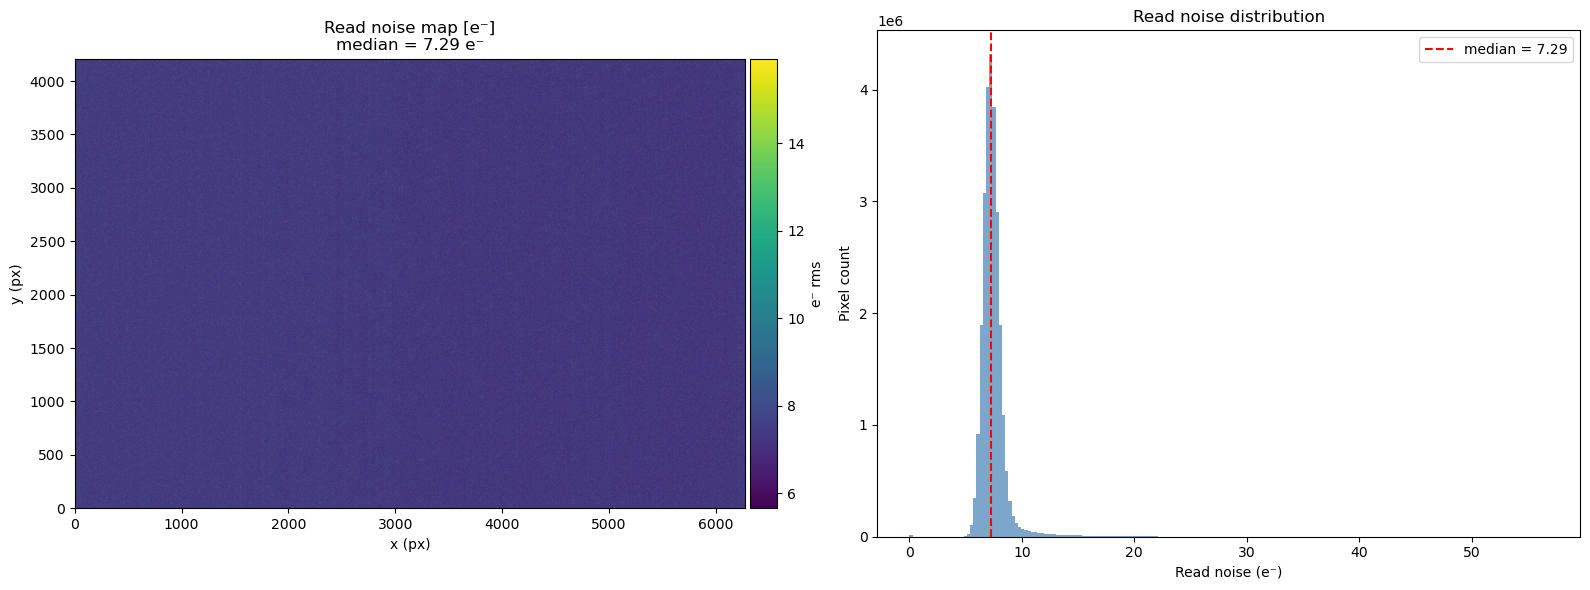

In [8]:
fig = plt.figure(figsize=(16, 6))
ct.noise_map_with_histogram(fig, read_noise_map_e, label="Read noise", unit="e⁻")
plt.savefig('tmpimg/read_noise_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 1f. Column & Row Banding — FFT Analysis
Collapse the read noise map along one axis to get 1D profiles, then FFT to identify periodic structure.

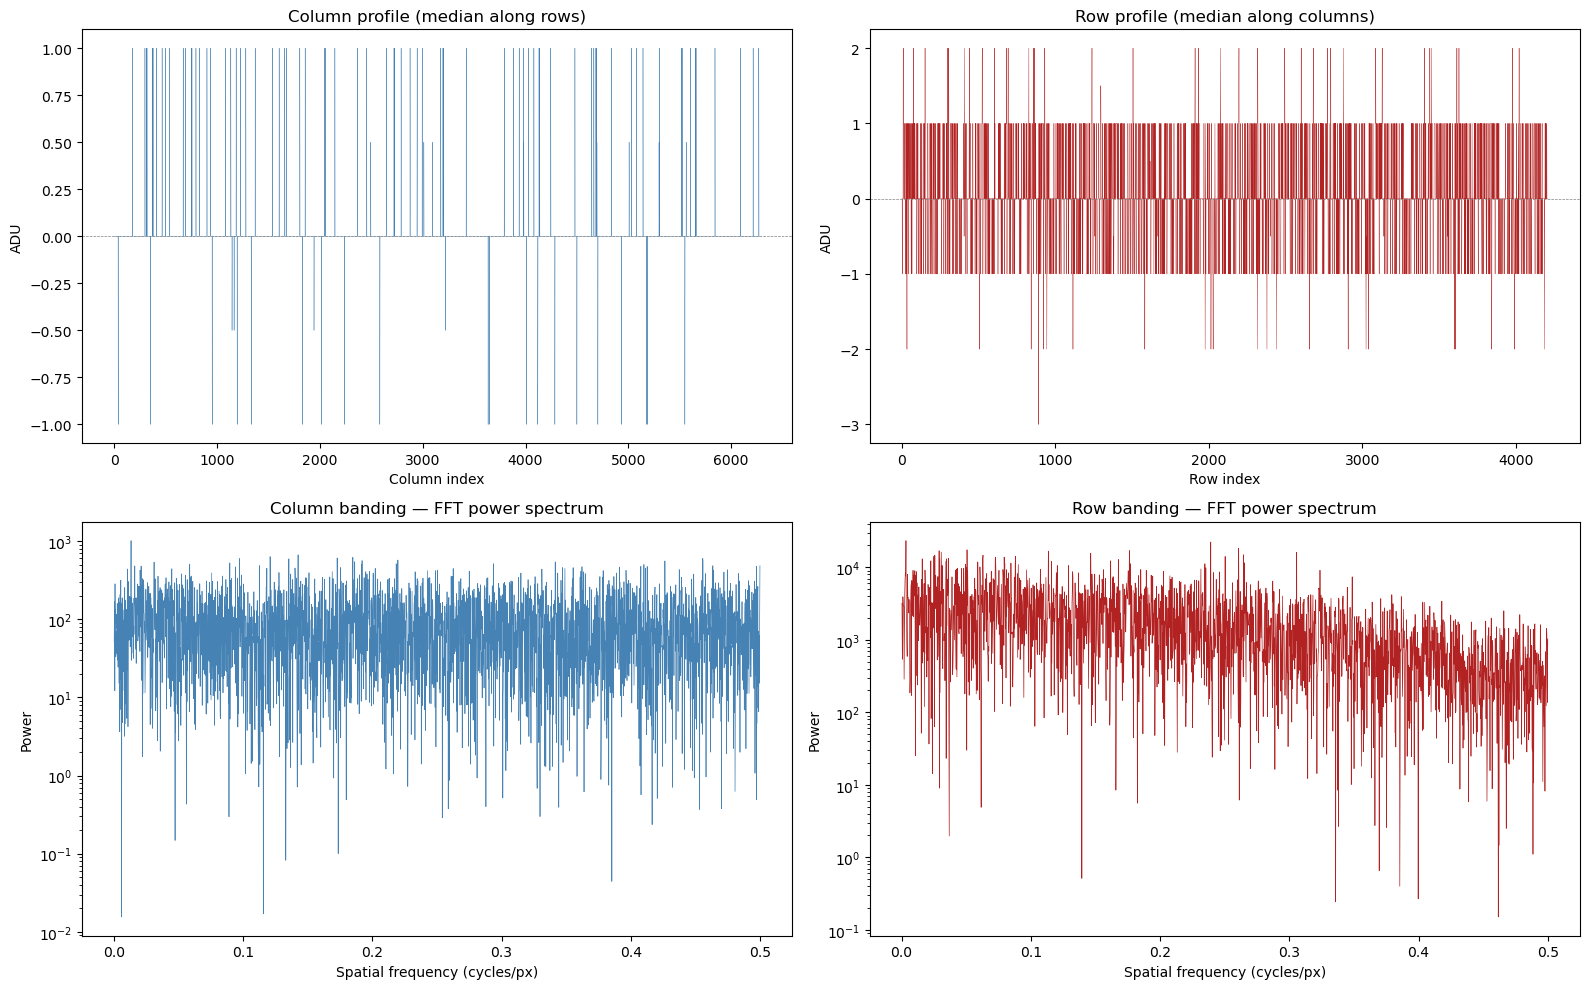


Col banding — top 5 frequencies:
  1. f = 0.01322 cyc/px  (period ~ 75.7 px)  power = 1015.5
  2. f = 0.14252 cyc/px  (period ~ 7.0 px)  power = 667.9
  3. f = 0.12086 cyc/px  (period ~ 8.3 px)  power = 634.5
  4. f = 0.18487 cyc/px  (period ~ 5.4 px)  power = 621.2
  5. f = 0.17277 cyc/px  (period ~ 5.8 px)  power = 609.1

Row banding — top 5 frequencies:
  1. f = 0.00333 cyc/px  (period ~ 300.7 px)  power = 23332.3
  2. f = 0.23919 cyc/px  (period ~ 4.2 px)  power = 22356.6
  3. f = 0.26081 cyc/px  (period ~ 3.8 px)  power = 18407.0
  4. f = 0.05059 cyc/px  (period ~ 19.8 px)  power = 17435.3
  5. f = 0.17625 cyc/px  (period ~ 5.7 px)  power = 17024.0


In [9]:
# ── Banding from representative difference image ──
diff_representative = bias_cube[1].astype(np.float64) - bias_cube[0].astype(np.float64)
banding_result = ct.row_column_noise(diff_representative)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Spatial profiles
axes[0,0].plot(banding_result.maps["col_profile"], lw=0.3, color='steelblue')
axes[0,0].set_title('Column profile (median along rows)')
axes[0,0].set_xlabel('Column index'); axes[0,0].set_ylabel('ADU')
axes[0,0].axhline(0, ls='--', color='gray', lw=0.5)

axes[0,1].plot(banding_result.maps["row_profile"], lw=0.3, color='firebrick')
axes[0,1].set_title('Row profile (median along columns)')
axes[0,1].set_xlabel('Row index'); axes[0,1].set_ylabel('ADU')
axes[0,1].axhline(0, ls='--', color='gray', lw=0.5)

# FFT power spectra
axes[1,0].semilogy(banding_result.maps["col_fft_freq"],
                   banding_result.maps["col_fft_power"], lw=0.5, color='steelblue')
axes[1,0].set_title('Column banding — FFT power spectrum')
axes[1,0].set_xlabel('Spatial frequency (cycles/px)'); axes[1,0].set_ylabel('Power')

axes[1,1].semilogy(banding_result.maps["row_fft_freq"],
                   banding_result.maps["row_fft_power"], lw=0.5, color='firebrick')
axes[1,1].set_title('Row banding — FFT power spectrum')
axes[1,1].set_xlabel('Spatial frequency (cycles/px)'); axes[1,1].set_ylabel('Power')

plt.tight_layout()
plt.savefig('tmpimg/banding_fft.png', dpi=150, bbox_inches='tight')
plt.show()

# Top frequencies
for axis in ['col', 'row']:
    print(f"\n{axis.capitalize()} banding — top 5 frequencies:")
    for r in range(1, 6):
        f = banding_result.scalar_summary[f"{axis}_freq_{r}"]
        p = banding_result.scalar_summary[f"{axis}_period_{r}"]
        pw = banding_result.scalar_summary[f"{axis}_power_{r}"]
        print(f"  {r}. f = {f:.5f} cyc/px  (period ~ {p:.1f} px)  power = {pw:.1f}")

## 1g. Histogram Gaussianity Test
Read noise should be Gaussian if dominated by amplifier thermal noise. We test with histogram + Gaussian overlay, Q-Q plot, D'Agostino-Pearson, and Anderson-Darling.

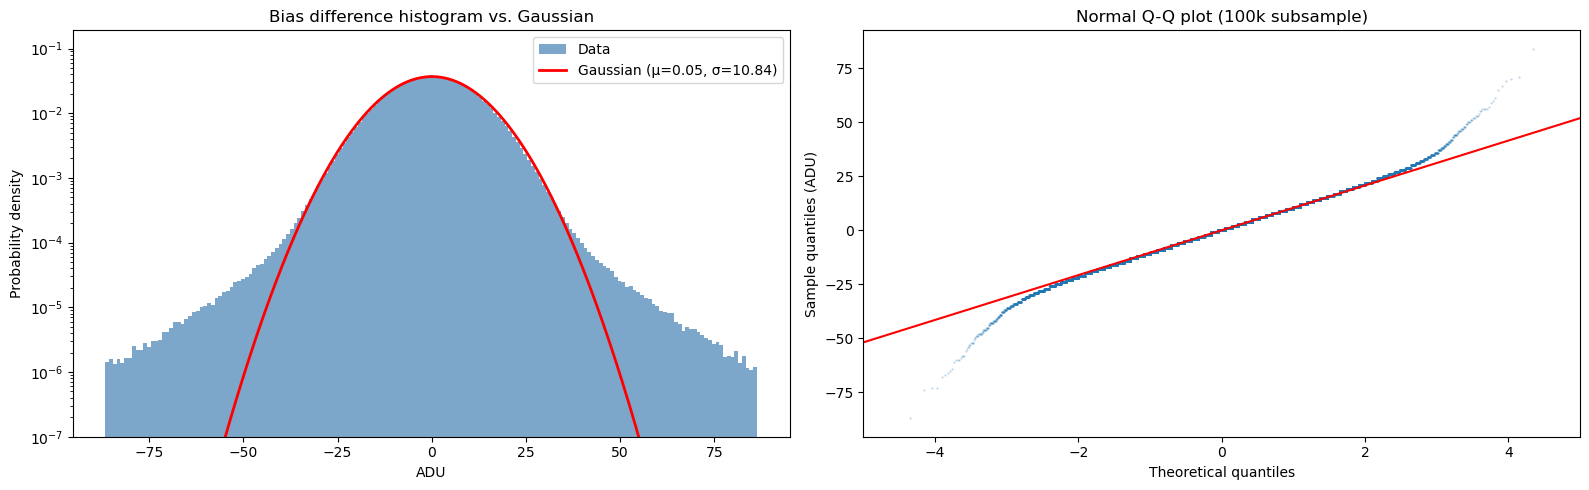

/Users/blu3/PycharmProjects/POLITE/caltools/stats.py:134: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = sp_stats.anderson(sample, dist="norm")


D'Agostino–Pearson: stat = 104.71, p = 1.8257e-23
Anderson–Darling:   stat = 3.1477
  15.0% critical value: 0.5610 ← reject
  10.0% critical value: 0.6310 ← reject
  5.0% critical value: 0.7520 ← reject
  2.5% critical value: 0.8730 ← reject
  1.0% critical value: 1.0350 ← reject

Skewness:        -0.0008
Excess kurtosis: 0.9825  (Gaussian = 0)


In [10]:
diff_flat = diff_representative.flatten()
mu_diff, sig_diff = np.mean(diff_flat), np.std(diff_flat)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram with Gaussian overlay
ct.histogram_gaussian_overlay(axes[0], diff_flat, n_sigma=8, log_scale=True)
axes[0].set_title('Bias difference histogram vs. Gaussian')

# Q-Q plot
rng = np.random.default_rng(42)
subsample = rng.choice(diff_flat, size=min(100_000, len(diff_flat)), replace=False)
osm, osr = stats.probplot(subsample, dist='norm', fit=False)
axes[1].plot(osm, osr, '.', markersize=1, alpha=0.3)
q25, q75 = np.percentile(subsample, [25, 75])
z25, z75 = stats.norm.ppf([0.25, 0.75])
slope_qq = (q75 - q25) / (z75 - z25)
inter_qq = q25 - slope_qq * z25
xlim = np.array([-5, 5])
axes[1].plot(xlim, slope_qq * xlim + inter_qq, 'r-', lw=1.5)
axes[1].set_xlabel('Theoretical quantiles'); axes[1].set_ylabel('Sample quantiles (ADU)')
axes[1].set_title('Normal Q-Q plot (100k subsample)'); axes[1].set_xlim(-5, 5)

plt.tight_layout()
plt.savefig('tmpimg/gaussianity_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical tests via caltools
gauss_tests = ct.gaussianity_tests(diff_flat)
print(f"D'Agostino–Pearson: stat = {gauss_tests['dagostino_stat']:.2f}, "
      f"p = {gauss_tests['dagostino_p']:.4e}")
print(f"Anderson–Darling:   stat = {gauss_tests['anderson_stat']:.4f}")
for sl, cv in zip(gauss_tests['anderson_significance'], gauss_tests['anderson_critical']):
    flag = " ← reject" if gauss_tests['anderson_stat'] > cv else ""
    print(f"  {sl}% critical value: {cv:.4f}{flag}")
print(f"\nSkewness:        {gauss_tests['skewness']:.4f}")
print(f"Excess kurtosis: {gauss_tests['kurtosis']:.4f}  (Gaussian = 0)")

## 1h. Hot Pixel Census from Bias Frames
Flag pixels with read noise > 5σ above the median.

In [ ]:
hot_5sig_mask = rn_result.maps["hot_5sig_mask"]
print(f"Read noise map: median = {rn_result.scalar_summary['ron_median_adu']:.3f} ADU, "
      f"MAD-σ = {rn_result.scalar_summary['mad_sigma_adu']:.3f} ADU\n")
for nsig in [3, 5, 10]:
    n_hot = rn_result.scalar_summary[f"hot_{nsig}sig"]
    frac = n_hot / rn_result.metadata["n_pixels"] * 100
    print(f"  >{nsig}σ hot pixels: {n_hot:,}  ({frac:.4f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(hot_5sig_mask.astype(float), origin='upper', cmap='Reds',
          interpolation='none', aspect='auto')
ax.set_title(f'Hot pixel map (>5σ): {np.sum(hot_5sig_mask):,} pixels')
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
plt.tight_layout()
plt.savefig('tmpimg/hot_pixels_bias.png', dpi=150, bbox_inches='tight')
plt.show()

## 1i. Per-Pixel Std vs Mean Signal
Plot the per-pixel temporal σ against per-pixel mean signal to separate stable pixels from high-variance candidates.

In [ ]:
pixel_mean = np.mean(bias_cube, axis=0)
pixel_std  = temporal_std_map

# Subsample via caltools
pm_sub, ps_sub = ct.sigma_vs_mean_2d(pixel_mean, pixel_std)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 2D histogram
h = axes[0].hist2d(pm_sub, ps_sub, bins=[200, 200], cmap='inferno', norm=LogNorm(), cmin=1)
axes[0].set_xlabel('Mean signal (ADU)')
axes[0].set_ylabel(r'Temporal $\sigma$ (ADU)')
axes[0].set_title(r'Per-pixel $\sigma$ vs mean signal (500k subsample)')
fig.colorbar(h[3], ax=axes[0], label='Pixel count')
med_mean, med_std = np.median(pixel_mean), np.median(pixel_std)
axes[0].axhline(med_std, ls='--', color='cyan', lw=1, alpha=0.7, label=rf'median $\sigma$ = {med_std:.2f}')
axes[0].axvline(med_mean, ls='--', color='lime', lw=1, alpha=0.7, label=f'median mean = {med_mean:.1f}')
axes[0].legend(fontsize=9)

# Marginal histograms grouped by std
pm_flat, ps_flat = pixel_mean.flatten(), pixel_std.flatten()
ron_median = np.median(ps_flat)
ron_mad = ct.mad_sigma(ps_flat)
thresholds = [ron_median + k * ron_mad for k in [0, 3, 5, 10, 20]]
colors = ['steelblue', 'mediumpurple', 'darkorange', 'crimson', 'black']
for i in range(len(thresholds)):
    lo = thresholds[i]
    hi = thresholds[i+1] if i+1 < len(thresholds) else ps_flat.max() + 1
    mask = (ps_flat >= lo) & (ps_flat < hi)
    n_pix = np.sum(mask)
    frac = n_pix / len(ps_flat) * 100
    lab = f'{lo:.1f} <= sig < {hi:.1f} ({frac:.2f}%)'
    if n_pix > 10:
        axes[1].hist(pm_flat[mask], bins=100, density=True, alpha=0.5,
                     color=colors[i % len(colors)], label=lab)
axes[1].set_xlabel('Mean signal (ADU)'); axes[1].set_ylabel('Density')
axes[1].set_title('Signal distribution grouped by temporal std')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('tmpimg/sigma_vs_mean.png', dpi=150, bbox_inches='tight')
plt.show()

for nsig in [3, 5, 10]:
    threshold = ron_median + nsig * ron_mad
    n_anom = np.sum(ps_flat > threshold)
    print(f"  >{nsig}-MAD-σ (>{threshold:.2f} ADU): {n_anom:,} pixels ({n_anom/len(ps_flat)*100:.4f}%)")

## 1j. Random Telegraph Noise Candidate Detection
RTN candidates have normal mean bias but anomalously high temporal std.

RTN candidate pixels:       18,907 (0.0715%)
High-bias pixels:           67,916 (0.2569%)


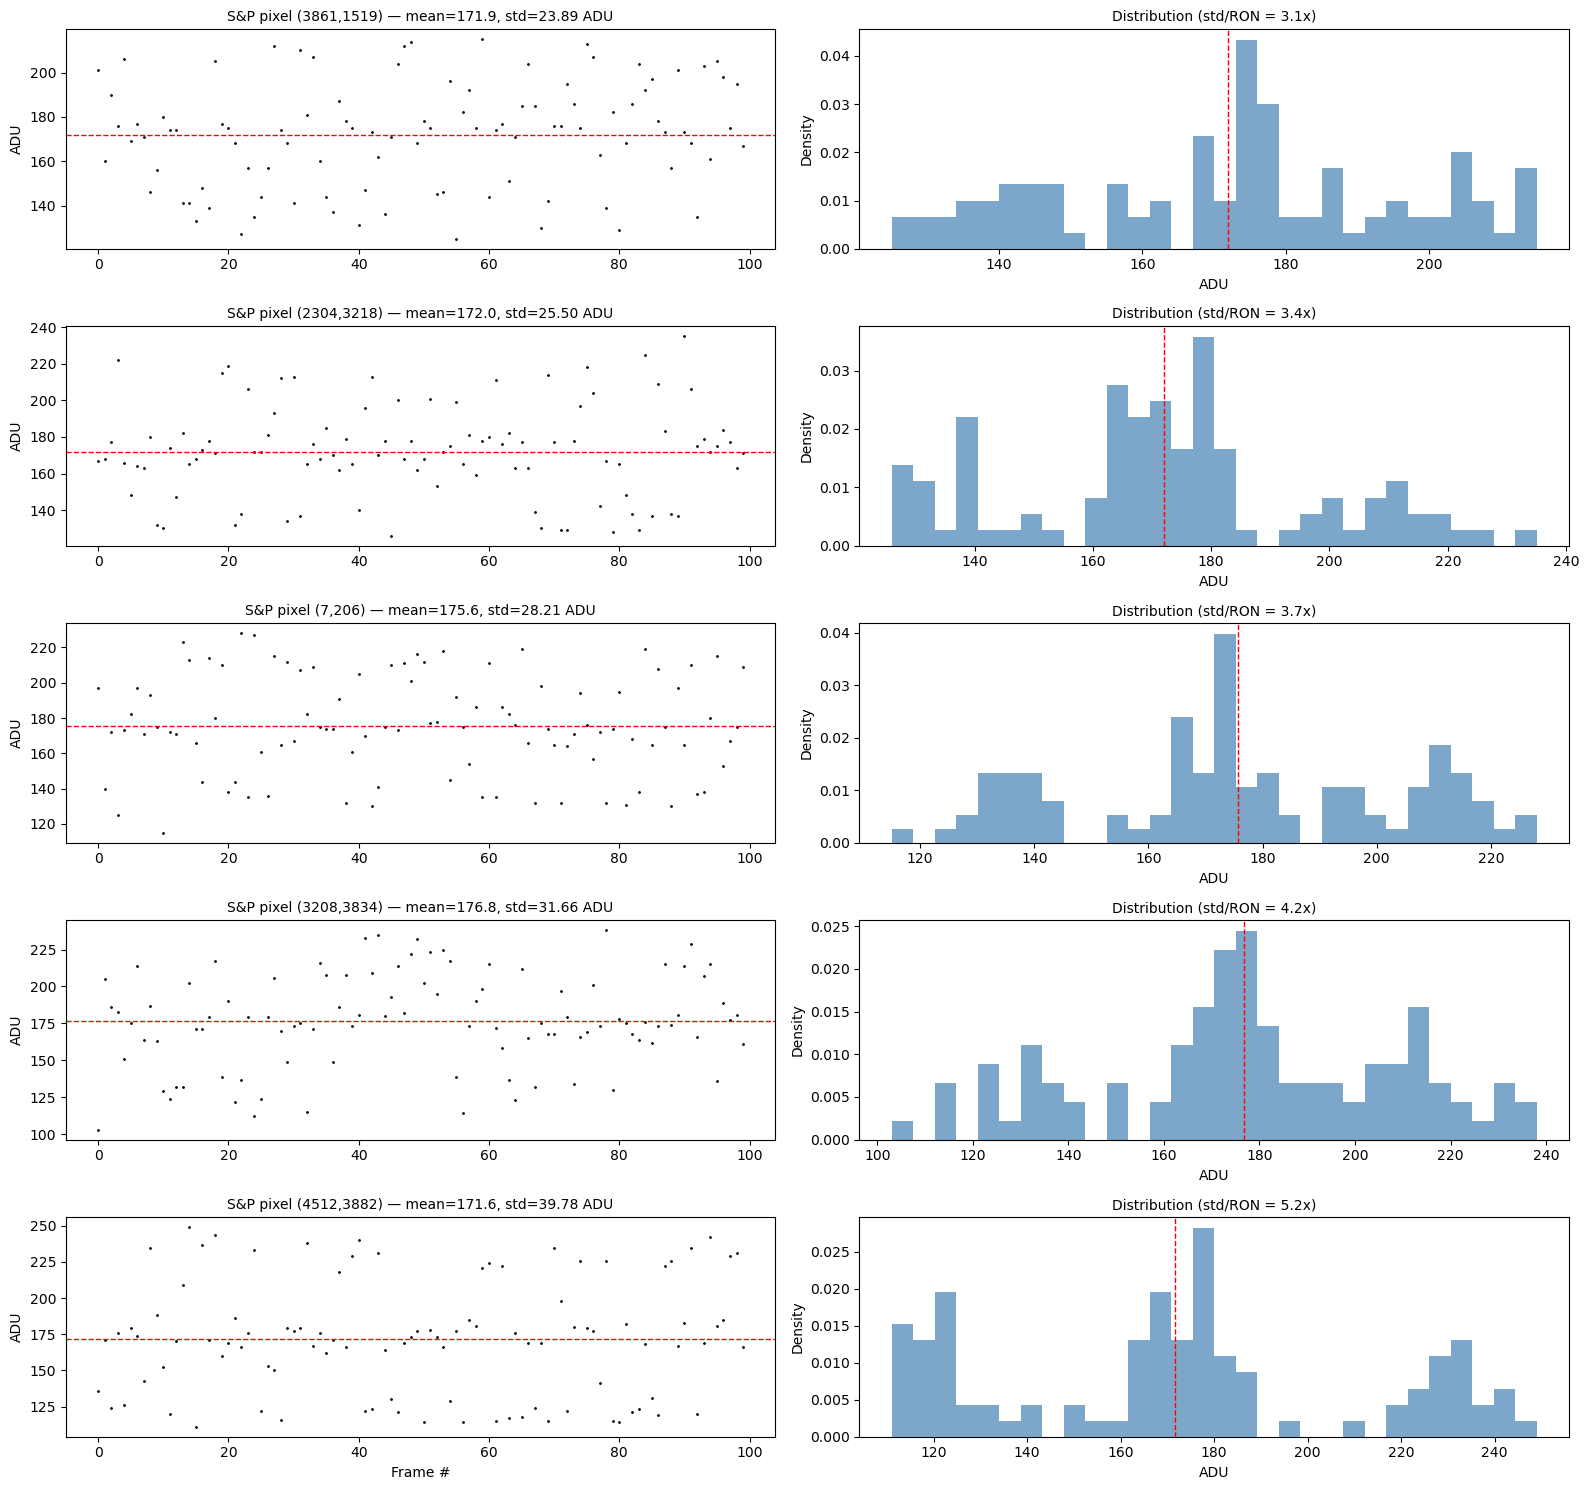

In [13]:
# ── RTN detection via caltools ──
rtn_result = ct.detect_rtn_pixels(bias_cube, config, sigma_threshold=3.0)

n_sp = rtn_result.scalar_summary["n_sp"]
n_high = rtn_result.scalar_summary["n_high_bias"]
n_total = rtn_result.metadata["n_total"]

print(f"RTN candidate pixels:       {n_sp:,} ({n_sp/n_total*100:.4f}%)")
print(f"High-bias pixels:           {n_high:,} ({n_high/n_total*100:.4f}%)")

# ── Example time series ──
sp_mask = rtn_result.maps["sp_mask"]
sp_ys, sp_xs = np.where(sp_mask)
examples = rtn_result.metadata.get("example_pixels", [])

if examples:
    fig, axes = plt.subplots(len(examples), 2, figsize=(16, 3*len(examples)))
    if len(examples) == 1:
        axes = axes[np.newaxis, :]
    for i, (py, px) in enumerate(examples):
        timeseries = bias_cube[:, py, px]
        mu_px = float(np.mean(timeseries))
        sig_px = float(np.std(timeseries))
        axes[i, 0].plot(timeseries, '.', markersize=2, color='black')
        axes[i, 0].axhline(mu_px, ls='--', color='red', lw=1)
        axes[i, 0].set_ylabel('ADU')
        axes[i, 0].set_title(f'RTN candidate ({px},{py}) — mean={mu_px:.1f}, std={sig_px:.2f} ADU', fontsize=10)
        if i == len(examples) - 1:
            axes[i, 0].set_xlabel('Frame #')
        axes[i, 1].hist(timeseries, bins=30, color='steelblue', alpha=0.7, density=True)
        axes[i, 1].axvline(mu_px, ls='--', color='red', lw=1)
        axes[i, 1].set_xlabel('ADU'); axes[i, 1].set_ylabel('Density')
        axes[i, 1].set_title(f'Distribution (std/RON = {sig_px/global_rms_ron:.1f}x)', fontsize=10)
    plt.tight_layout()
    plt.savefig('tmpimg/sp_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1k. Step 1 Summary

In [14]:
print("=" * 65)
print("  STEP 1: READ NOISE CHARACTERIZATION — QHY268M (IMX571)")
print("=" * 65)
print(f"  Sensor temp:           {config.temperature_c}°C")
print(f"  Assumed gain:          {GAIN_E_PER_ADU} e⁻/ADU (Mode 0, Gain 0)")
print(f"  Bias frames used:      {len(bias_files)}")
print(f"  Frame size:            {nx} × {ny}")
print()
print(f"  Read noise (map med):  {rn_result.scalar_summary['ron_median_adu']:.3f} ADU"
      f" = {rn_result.scalar_summary['ron_median_e']:.3f} e⁻")
print(f"  Read noise (map rms):  {rn_result.scalar_summary['ron_rms_adu']:.3f} ADU"
      f" = {rn_result.scalar_summary['ron_rms_e']:.3f} e⁻")
print(f"  Temporal σ (w/ FPN):   {np.mean(temporal_std_map):.3f} ADU"
      f" = {np.mean(temporal_std_map)*GAIN_E_PER_ADU:.3f} e⁻")
print()
print(f"  Hot pixels (>5σ):      {rn_result.scalar_summary['hot_5sig']:,}")
print(f"  RTN candidates:        {rtn_result.scalar_summary['n_sp']:,}"
      f" ({rtn_result.scalar_summary['frac_sp']*100:.4f}%)")
print(f"  Skewness:              {gauss_tests['skewness']:.4f}")
print(f"  Excess kurtosis:       {gauss_tests['kurtosis']:.4f}")
print("=" * 65)

  STEP 1: READ NOISE CHARACTERIZATION — QHY268M (IMX571)
  Sensor temp:           -5.5°C
  Assumed gain:          1.0 e⁻/ADU (Mode 0, Gain 0)
  Bias frames used:      100
  Frame size:            6280 × 4210

  Read noise (map med):  7.286 ADU = 7.286 e⁻
  Read noise (map rms):  7.590 ADU = 7.590 e⁻
  Temporal σ (w/ FPN):   7.437 ADU = 7.437 e⁻

  Hot pixels (>5σ):      522,540
  RTN candidates:        18,907 (0.0715%)
  Skewness:              -0.0008
  Excess kurtosis:       0.9825


In [15]:
# ── Free memory from bias cube ──
del bias_cube
gc.collect()
print("Bias cube freed.")

Bias cube freed.


# ─── Step 2: Gain Measurement via Photon Transfer Curve ───

The PTC relates the mean signal in flat frames to the variance of their difference:

$\mathrm{Var}(F_1 - F_2) / 2 \;=\; \sigma^2_{\mathrm{read}} \;+\; \bar{S} / G$

Slope of Var vs S gives 1/G. We use `caltools.photon_transfer_curve_with_ron()` with the Step 1 RON² as a prior.

In [16]:
# ── Central ROI ──
roi = config.central_roi(height=2000, width=3000)
print(f"ROI: rows {roi[0].start}:{roi[0].stop}, cols {roi[1].start}:{roi[1].stop}")

# ── PTC groups ──
ptc_groups = {
    '1s ramp': flat1_files,
    '2s ramp': flat2_files,
    '5s ramp': flat5_ramp_files,
    '5s PRNU': flat5_prnu_files,
    '10s ramp': flat10_files,
    '15s ramp': flat15_files,
    '20s ramp': flat20_files,
    '30s sky': flat30_files,
    '60s sky': flat60_files,
    '120s sky': flat120_files,
}

# RON² from Step 1
ron_var_step1 = rn_result.scalar_summary["ron_rms_adu"] ** 2

# ── PTC with external RON prior ──
ptc_result = ct.photon_transfer_curve_with_ron(
    ptc_groups, master_bias, config,
    ron_var_adu2=ron_var_step1, roi=roi,
)

s = ptc_result.scalar_summary
print(f"Step 1 RON² prior: {ron_var_step1:.3f} ADU²")
print(f"\nFit 1 — Free intercept:")
print(f"  Slope 1/G = {s['slope_free']:.6f}  →  G = {s['gain_free_e_per_adu']:.4f} e⁻/ADU")
print(f"  Uncertainty σ_G = {s['gain_free_uncertainty']:.4f}")
print(f"  Intercept = {s['intercept_free']:.3f} ADU²  (RON = {s['ron_from_intercept_adu']:.3f} ADU)")
print(f"\nFit 2 — Fixed intercept (= Step 1 RON²):")
print(f"  Slope 1/G = {s['slope_fixed']:.6f}  →  G = {s['gain_fixed_e_per_adu']:.4f} e⁻/ADU")
print(f"\nTotal PTC pairs: {s['n_pairs']:.0f}")
print(f"Signal range: {s['signal_min_adu']:.1f} – {s['signal_max_adu']:.1f} ADU")

ROI: rows 1105:3105, cols 1640:4640
Step 1 RON² prior: 57.607 ADU²

Fit 1 — Free intercept:
  Slope 1/G = 24.295070  →  G = 0.0412 e⁻/ADU
  Uncertainty σ_G = 0.0000
  Intercept = -1728.245 ADU²  (RON = 0.000 ADU)

Fit 2 — Fixed intercept (= Step 1 RON²):
  Slope 1/G = 21.401902  →  G = 0.0467 e⁻/ADU

Total PTC pairs: 630
Signal range: 8.9 – 1064.0 ADU


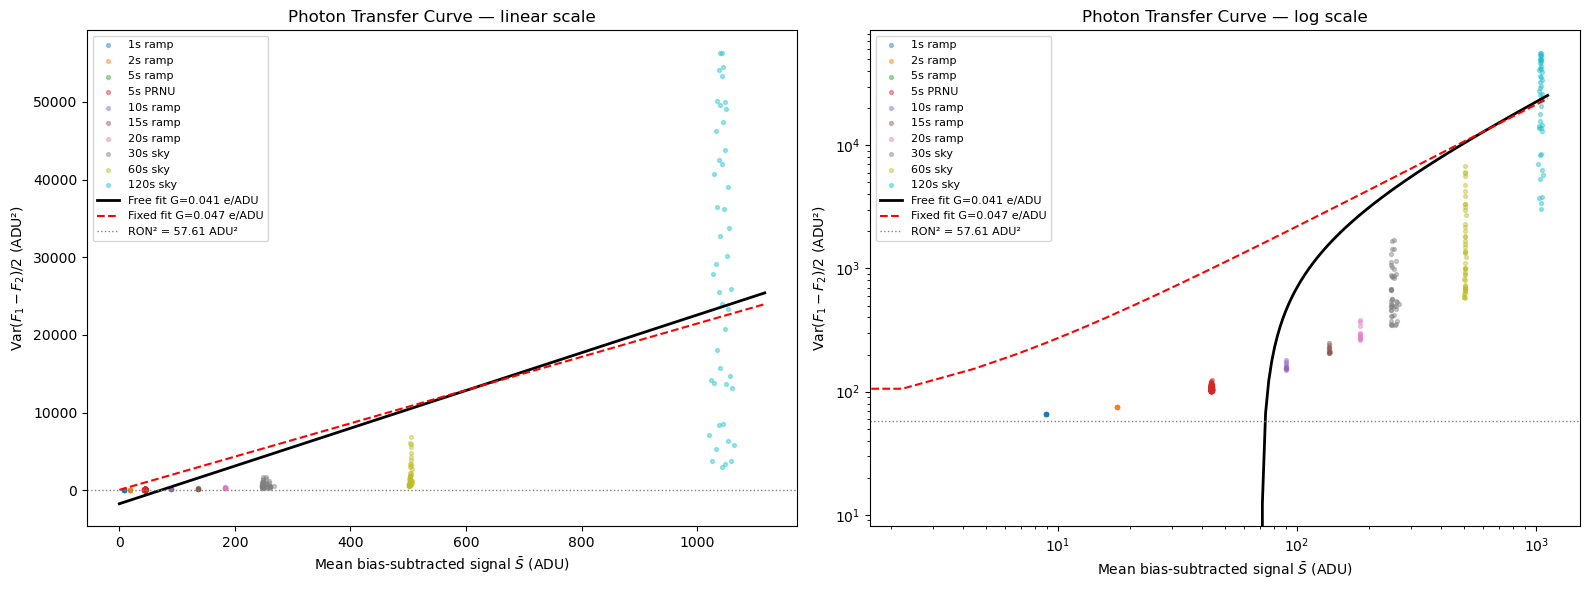

In [17]:
# ── PTC Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ct.ptc_plot(axes[0], ptc_result, log_scale=False)
axes[0].set_title('Photon Transfer Curve — linear scale')
ct.ptc_plot(axes[1], ptc_result, log_scale=True)
axes[1].set_title('Photon Transfer Curve — log scale')
plt.tight_layout()
plt.savefig('tmpimg/ptc_gain.png', dpi=150, bbox_inches='tight')
plt.show()

## 2d. Gain Update & Revised Read Noise
Use the fixed-intercept gain if the two estimates agree within ~10%.

In [18]:
s = ptc_result.scalar_summary
gain_free = s["gain_free_e_per_adu"]
gain_fixed = s["gain_fixed_e_per_adu"]
sigma_gain_free = s["gain_free_uncertainty"]

frac_diff = abs(gain_free - gain_fixed) / gain_fixed
if frac_diff < 0.10:
    GAIN_E_PER_ADU = gain_fixed
    gain_source = "PTC fixed-intercept"
    print(f"Free and fixed fits agree within {frac_diff*100:.1f}% — using fixed-intercept gain.")
else:
    GAIN_E_PER_ADU = gain_free
    gain_source = "PTC free-intercept"
    print(f"WARNING: Free and fixed fits differ by {frac_diff*100:.1f}% (>10%).")
    print(f"  Using free-intercept gain as primary estimate.")

# Update config with measured gain
config = config.with_gain(GAIN_E_PER_ADU)

ron_adu_median = rn_result.scalar_summary["ron_median_adu"]
ron_adu_rms = rn_result.scalar_summary["ron_rms_adu"]
ron_from_fit = s["ron_from_intercept_adu"]

print()
print("=" * 65)
print("  STEP 2: GAIN MEASUREMENT — QHY268M (IMX571)")
print("=" * 65)
print(f"  Method:              PTC ({s['n_pairs']:.0f} pairs)")
print(f"  Signal range:        {s['signal_min_adu']:.1f} – {s['signal_max_adu']:.1f} ADU")
print()
print(f"  Gain (free fit):     {gain_free:.4f} {pm} {sigma_gain_free:.4f} e⁻/ADU")
print(f"  Gain (fixed fit):    {gain_fixed:.4f} e⁻/ADU")
print(f"  --> GAIN_E_PER_ADU = {GAIN_E_PER_ADU:.4f} e⁻/ADU  [{gain_source}]")
print()
print(f"  Read noise (corrected with measured gain):")
print(f"    Map median:  {ron_adu_median:.3f} ADU = {ron_adu_median*GAIN_E_PER_ADU:.3f} e⁻")
print(f"    Map RMS:     {ron_adu_rms:.3f} ADU = {ron_adu_rms*GAIN_E_PER_ADU:.3f} e⁻")
print(f"    PTC intercept: {ron_from_fit:.3f} ADU = {ron_from_fit*GAIN_E_PER_ADU:.3f} e⁻")
print("=" * 65)

  Using free-intercept gain as primary estimate.

  STEP 2: GAIN MEASUREMENT — QHY268M (IMX571)
  Method:              PTC (630 pairs)
  Signal range:        8.9 – 1064.0 ADU

  Gain (free fit):     0.0412 ± 0.0000 e⁻/ADU
  Gain (fixed fit):    0.0467 e⁻/ADU
  --> GAIN_E_PER_ADU = 0.0412 e⁻/ADU  [PTC free-intercept]

  Read noise (corrected with measured gain):
    Map median:  7.286 ADU = 0.300 e⁻
    Map RMS:     7.590 ADU = 0.312 e⁻
    PTC intercept: 0.000 ADU = 0.000 e⁻


# ─── Step 3: Bias/Offset Characterization ───

Characterize the bias offset level: spatial structure, temporal stability over the 100-frame sequence, and statistics.

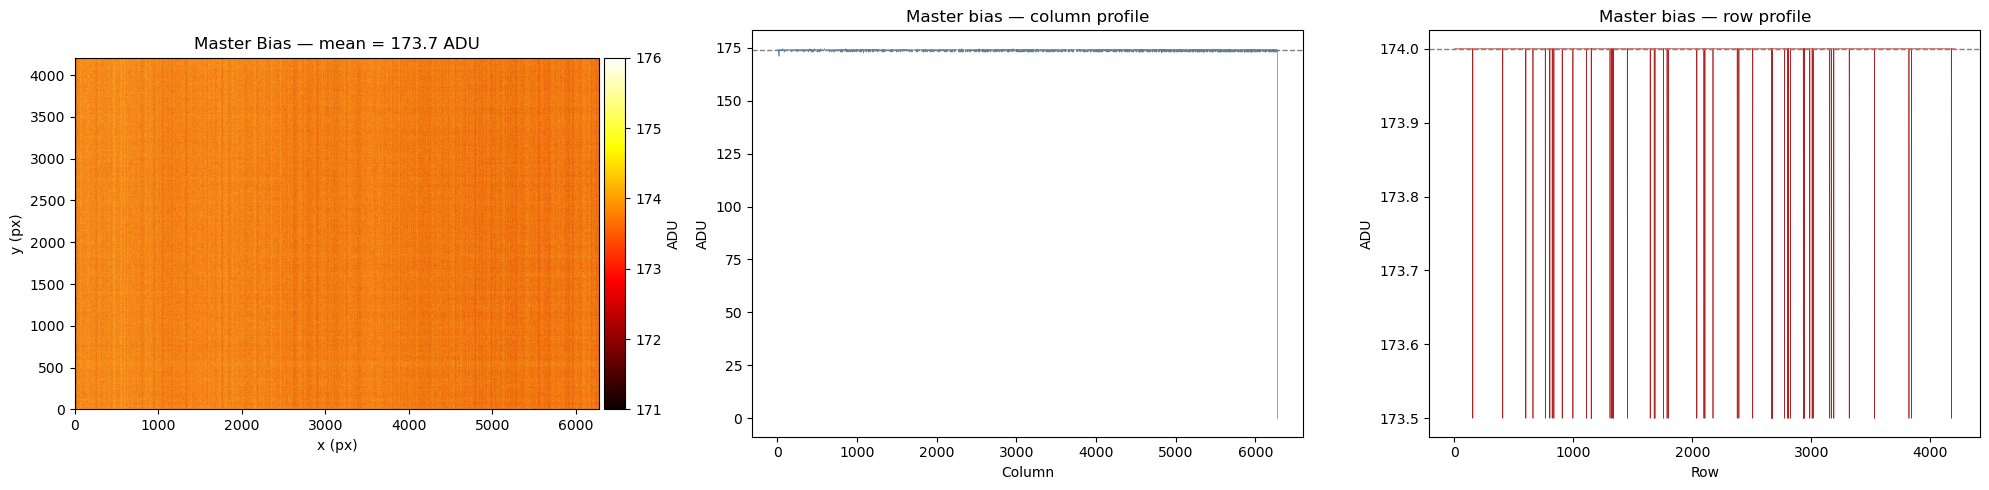

In [19]:
# ── 3a. Bias spatial structure ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ct.image_with_colorbar(axes[0], master_bias, label='ADU', cmap=cdef,
                       percentile_clip=(1, 99))
axes[0].set_title(f'Master Bias — mean = {master_bias.mean():.1f} ADU')

# Row and column profiles of master bias
axes[1].plot(np.median(master_bias, axis=0), lw=0.5, color='steelblue')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('ADU')
axes[1].set_title('Master bias — column profile')
axes[1].axhline(np.median(master_bias), ls='--', color='gray', lw=1)

axes[2].plot(np.median(master_bias, axis=1), lw=0.5, color='firebrick')
axes[2].set_xlabel('Row'); axes[2].set_ylabel('ADU')
axes[2].set_title('Master bias — row profile')
axes[2].axhline(np.median(master_bias), ls='--', color='gray', lw=1)

plt.tight_layout()
plt.savefig('tmpimg/bias_structure.png', dpi=150, bbox_inches='tight')
plt.show()

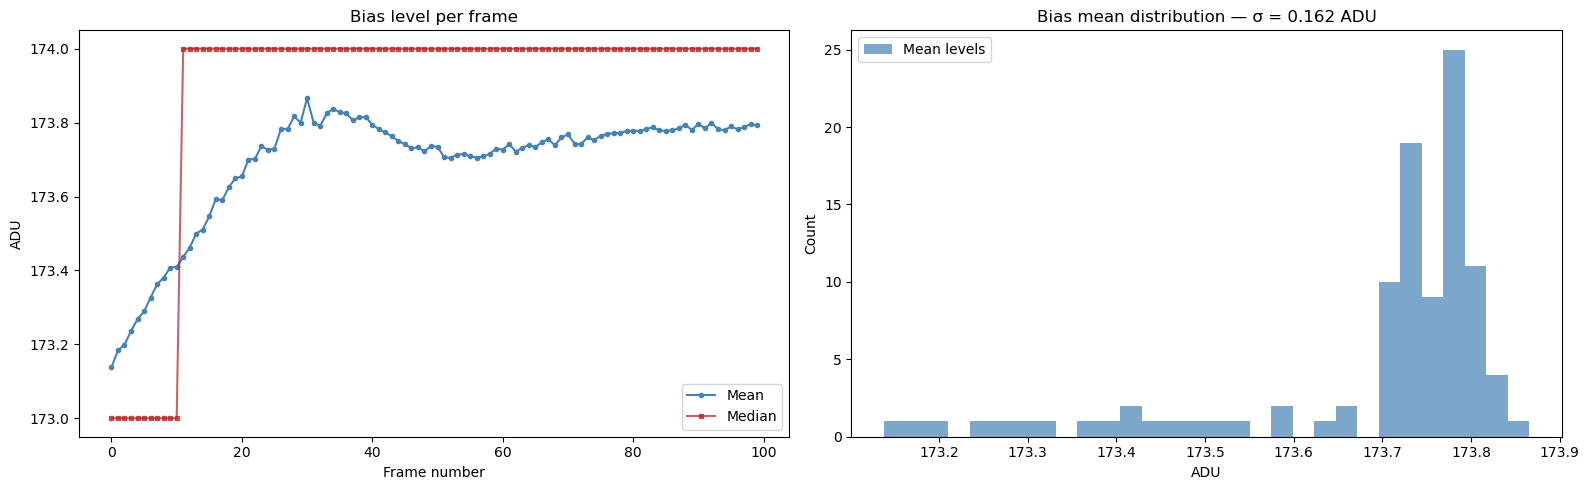

Bias mean range: 173.14 – 173.87 ADU
Bias mean std:   0.1617 ADU = 0.0067 e⁻
Bias MAD-σ:      0.0563 ADU


In [20]:
# ── 3b. Bias temporal stability ──
timestamps = ct.get_timestamps(bias_files)

# Per-frame mean level (re-read frames one at a time to avoid reloading cube)
frame_means = np.array([float(np.mean(ct.load_frame(f))) for f in bias_files])
frame_medians = np.array([float(np.median(ct.load_frame(f))) for f in bias_files])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(frame_means, 'o-', markersize=3, color='steelblue', label='Mean')
axes[0].plot(frame_medians, 's-', markersize=3, color='firebrick', alpha=0.7, label='Median')
axes[0].set_xlabel('Frame number'); axes[0].set_ylabel('ADU')
axes[0].set_title('Bias level per frame')
axes[0].legend()

axes[1].hist(frame_means, bins=30, color='steelblue', alpha=0.7, label='Mean levels')
axes[1].set_xlabel('ADU'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Bias mean distribution — σ = {np.std(frame_means):.3f} ADU')
axes[1].legend()

plt.tight_layout()
plt.savefig('tmpimg/bias_stability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Bias mean range: {frame_means.min():.2f} – {frame_means.max():.2f} ADU")
print(f"Bias mean std:   {np.std(frame_means):.4f} ADU "
      f"= {np.std(frame_means)*GAIN_E_PER_ADU:.4f} e⁻")
print(f"Bias MAD-σ:      {ct.mad_sigma(frame_means):.4f} ADU")

In [21]:
# ── 3c. Step 3 Summary ──
print("=" * 65)
print("  STEP 3: BIAS / OFFSET CHARACTERIZATION")
print("=" * 65)
print(f"  Master bias mean:    {master_bias.mean():.2f} ADU")
print(f"  Master bias median:  {np.median(master_bias):.2f} ADU")
print(f"  Frame-to-frame σ:    {np.std(frame_means):.4f} ADU"
      f" = {np.std(frame_means)*GAIN_E_PER_ADU:.4f} e⁻")
print(f"  Spatial σ (bias):    {np.std(master_bias):.3f} ADU")
print("=" * 65)

  STEP 3: BIAS / OFFSET CHARACTERIZATION
  Master bias mean:    173.68 ADU
  Master bias median:  174.00 ADU
  Frame-to-frame σ:    0.1617 ADU = 0.0067 e⁻
  Spatial σ (bias):    4.511 ADU


# ─── Step 4: Dark Current ───

Measure dark current rate from multiple exposure times (30s, 120s, 300s).
Characterize spatial structure (amp glow), warm/hot pixels, and temperature dependence.

Dark current rate: 0.004372 ADU/pix/s = 0.000180 e⁻/pix/s
Offset:            0.0820 ADU
R² =               0.997910


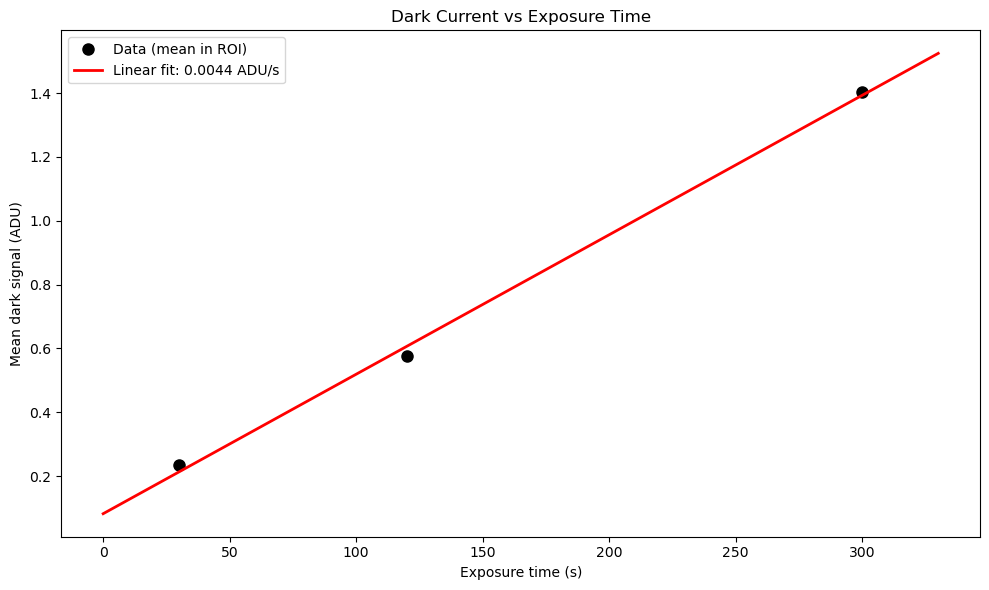

In [22]:
# ── 4a. Dark current vs exposure time ──
dark_groups = {
    30.0: dark30_files,
    120.0: dark120_files,
    300.0: dark300_files,
}

dc_result = ct.dark_current_vs_exposure(dark_groups, master_bias, config, roi=roi)
ds = dc_result.scalar_summary

print(f"Dark current rate: {ds['dark_rate_adu_per_s']:.6f} ADU/pix/s "
      f"= {ds['dark_rate_e_per_s']:.6f} e⁻/pix/s")
print(f"Offset:            {ds['offset_adu']:.4f} ADU")
print(f"R² =               {ds['r_squared']:.6f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
exptimes = dc_result.metadata["exptimes"]
mean_signals = dc_result.metadata["mean_signals_adu"]
t_plot = np.linspace(0, exptimes.max() * 1.1, 200)
ax.plot(exptimes, mean_signals, 'ko', markersize=8, label='Data (mean in ROI)')
ax.plot(t_plot, np.polyval(dc_result.metadata["fit_coeffs"], t_plot),
        'r-', lw=2, label=f'Linear fit: {ds["dark_rate_adu_per_s"]:.4f} ADU/s')
ax.set_xlabel('Exposure time (s)'); ax.set_ylabel('Mean dark signal (ADU)')
ax.set_title('Dark Current vs Exposure Time')
ax.legend()
plt.tight_layout()
plt.savefig('tmpimg/dark_current_vs_exp.png', dpi=150, bbox_inches='tight')
plt.show()

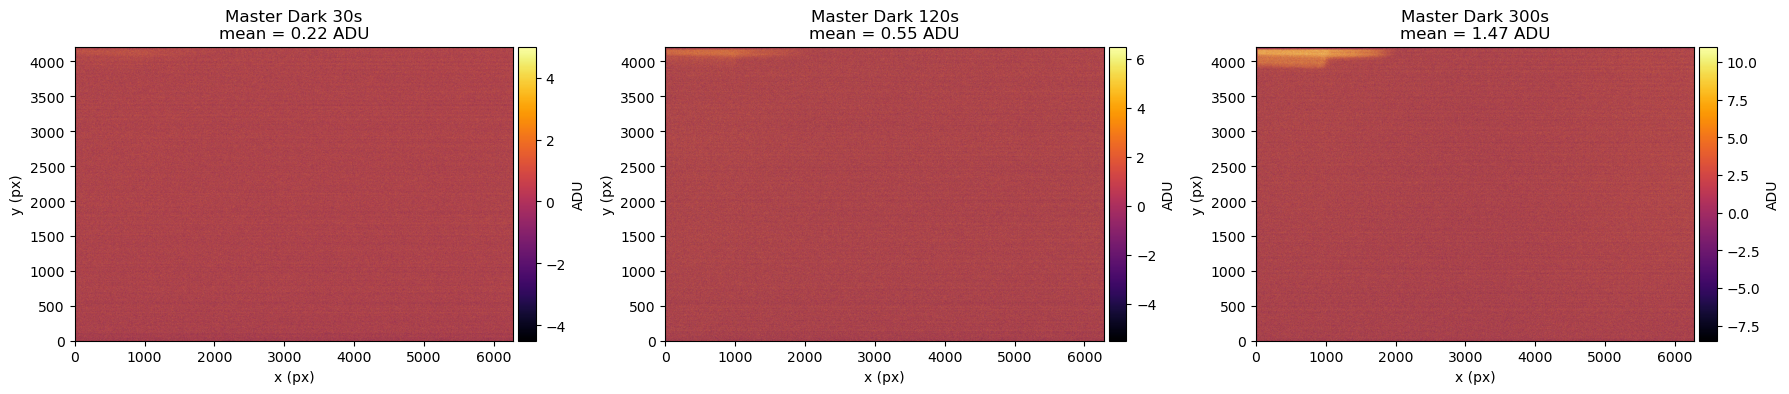

      30s: mean = 0.215 ADU = 0.009 e⁻,  std = 15.292 ADU
     120s: mean = 0.552 ADU = 0.023 e⁻,  std = 35.681 ADU
     300s: mean = 1.469 ADU = 0.060 e⁻,  std = 53.558 ADU


In [23]:
# ── 4b. Dark spatial structure (glow maps) ──
master_darks = {}
for exp, paths in sorted(dark_groups.items()):
    master_darks[exp] = ct.master_dark(paths, master_bias)

glow_result = ct.dark_spatial_structure(master_darks, config)

n_exp = len(master_darks)
fig, axes = plt.subplots(1, n_exp, figsize=(6 * n_exp, 5))
if n_exp == 1:
    axes = [axes]
for i, (exp, md) in enumerate(sorted(master_darks.items())):
    ct.image_with_colorbar(axes[i], md, label='ADU', cmap='inferno',
                           percentile_clip=(1, 99))
    axes[i].set_title(f'Master Dark {exp:.0f}s\nmean = {np.mean(md):.2f} ADU')
plt.tight_layout()
plt.savefig('tmpimg/dark_glow.png', dpi=150, bbox_inches='tight')
plt.show()

for exp in sorted(master_darks.keys()):
    gs = glow_result.scalar_summary
    print(f"  {exp:6.0f}s: mean = {gs[f'mean_{exp}s_adu']:.3f} ADU"
          f" = {gs[f'mean_{exp}s_e']:.3f} e⁻,  std = {gs[f'std_{exp}s_adu']:.3f} ADU")

In [ ]:
# ── 4c. Dark current vs temperature ──
# Extract temperatures from each dark group
temp_groups = {}
for exp, paths in dark_groups.items():
    temps = [fits.getheader(p)['CCD-TEMP'] for p in paths]
    mean_temp = np.mean(temps)
    temp_groups[mean_temp] = (paths, exp)

if len(temp_groups) >= 2:
    dc_temp_result = ct.dark_current_vs_temperature(temp_groups, master_bias, config, roi=roi)
    dt = dc_temp_result.scalar_summary
    print(f"Temperature range: {dt.get('temp_range_c', 0):.1f}°C")
    temps_c = dt.get('temperatures_c', [])
    rates_e = dt.get('dark_rates_e_per_s', [])
    print(f"Temperatures: [{', '.join(f'{t:.2f}' for t in temps_c)}] °C")
    print(f"Dark rates (e⁻/s): [{', '.join(f'{r:.6e}' for r in rates_e)}]")
    if dt.get('arrhenius_fit_failed', 0):
        print("  Arrhenius fit failed or was not attempted (narrow T range)")
    else:
        print(f"  Arrhenius Ea = {dt.get('arrhenius_Ea_eV', 0):.3f} {pm} {dt.get('arrhenius_Ea_err_eV', 0):.3f} eV")
else:
    print("  Not enough temperature diversity for Arrhenius fit")

In [25]:
# ── 4d. Warm pixel census ──
warm_result = ct.warm_pixel_map(dark_groups, master_bias, config, threshold_sigma=5.0, roi=roi)

print(f"\nWarm pixel census (>5σ above median dark):")
for exp in sorted(dark_groups.keys()):
    ws = warm_result.scalar_summary
    n_w = ws.get(f"n_warm_{exp}s", 0)
    frac_w = ws.get(f"frac_warm_{exp}s", 0)
    print(f"  {exp:6.0f}s: {n_w:,.0f} warm pixels ({frac_w*100:.4f}%)")


Warm pixel census (>5σ above median dark):
      30s: 3,036 warm pixels (0.0506%)
     120s: 7,213 warm pixels (0.1202%)
     300s: 9,907 warm pixels (0.1651%)


In [26]:
# ── 4e. Step 4 Summary ──
print("=" * 65)
print("  STEP 4: DARK CURRENT — QHY268M (IMX571)")
print("=" * 65)
print(f"  Gain:                {GAIN_E_PER_ADU:.4f} e⁻/ADU")
print(f"  Dark rate:           {ds['dark_rate_adu_per_s']:.6f} ADU/s"
      f" = {ds['dark_rate_e_per_s']:.6f} e⁻/pix/s")
print(f"  Linear fit R²:      {ds['r_squared']:.6f}")
print(f"  Exposure times:      {list(sorted(dark_groups.keys()))} s")
print("=" * 65)

  STEP 4: DARK CURRENT — QHY268M (IMX571)
  Gain:                0.0412 e⁻/ADU
  Dark rate:           0.004372 ADU/s = 0.000180 e⁻/pix/s
  Linear fit R²:      0.997910
  Exposure times:      [30.0, 120.0, 300.0] s


# ─── Step 5: Full PTC Analysis & Full Well Capacity ───

Extend the PTC analysis with FWC estimation and noise decomposition (RON + shot noise).

In [27]:
# ── 5a. Full Well Capacity ──
fwc_result = ct.full_well_capacity(ptc_result, config)
fs = fwc_result.scalar_summary

print(f"Full Well Capacity:")
print(f"  FWC = {fs['fwc_adu']:.1f} ADU = {fs['fwc_e']:.1f} e⁻")
if fs['is_lower_bound']:
    print(f"  WARNING: LOWER BOUND — data does not reach PTC turnover")
    print(f"  Max observed signal: {fs['max_signal_adu']:.1f} ADU = {fs['max_signal_e']:.1f} e⁻")
else:
    print(f"  PTC turnover detected at {fwc_result.metadata['turnover_adu']:.1f} ADU")

print(f"\n  Reference: QHY268M/IMX571 expected FWC ~51,000 e⁻ at Gain 0")

Full Well Capacity:
  FWC = 43.6 ADU = 1.8 e⁻
  PTC turnover detected at 43.6 ADU

  Reference: QHY268M/IMX571 expected FWC ~51,000 e⁻ at Gain 0


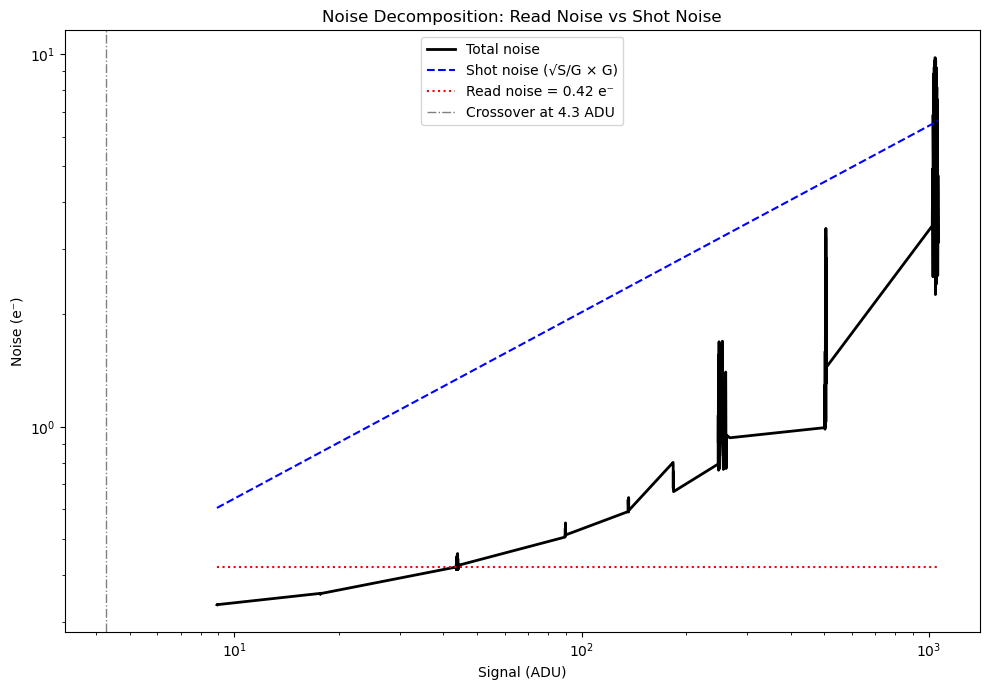

Crossover signal: 4.3 ADU = 0.2 e⁻
  Below this, read noise dominates; above, shot noise dominates.


In [28]:
# ── 5b. Noise decomposition ──
nd_result = ct.noise_decomposition(
    ptc_result.metadata["signal"],
    ptc_result.metadata["variance"],
    config,
)
nds = nd_result.scalar_summary

fig, ax = plt.subplots(figsize=(10, 7))
maps = nd_result.maps
ax.plot(maps["signal_adu"], maps["total_noise_e"], 'k-', lw=2, label='Total noise')
ax.plot(maps["signal_adu"], maps["shot_noise_e"], 'b--', lw=1.5, label='Shot noise (√S/G × G)')
ax.plot(maps["signal_adu"], maps["read_noise_e"], 'r:', lw=1.5, label=f'Read noise = {nds["ron_e"]:.2f} e⁻')
ax.axvline(nds["crossover_signal_adu"], ls='-.', color='gray', lw=1,
           label=f'Crossover at {nds["crossover_signal_adu"]:.1f} ADU')
ax.set_xlabel('Signal (ADU)'); ax.set_ylabel('Noise (e⁻)')
ax.set_title('Noise Decomposition: Read Noise vs Shot Noise')
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('tmpimg/noise_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Crossover signal: {nds['crossover_signal_adu']:.1f} ADU = {nds['crossover_signal_e']:.1f} e⁻")
print(f"  Below this, read noise dominates; above, shot noise dominates.")

In [29]:
# ── 5c. Step 5 Summary ──
print("=" * 65)
print("  STEP 5: FULL PTC & FULL WELL CAPACITY")
print("=" * 65)
print(f"  FWC:            {fs['fwc_adu']:.1f} ADU = {fs['fwc_e']:.1f} e⁻"
      + (" (lower bound)" if fs['is_lower_bound'] else ""))
print(f"  Crossover:      {nds['crossover_signal_adu']:.1f} ADU = {nds['crossover_signal_e']:.1f} e⁻")
print(f"  RON (from PTC): {nds['ron_e']:.2f} e⁻")
print("=" * 65)

  STEP 5: FULL PTC & FULL WELL CAPACITY
  FWC:            43.6 ADU = 1.8 e⁻
  Crossover:      4.3 ADU = 0.2 e⁻
  RON (from PTC): 0.42 e⁻


# ─── Step 6: Linearity ───

Measure signal vs exposure linearity from the flat-field ramp (1s, 2s, 5s, 10s, 15s, 20s).
Compute fractional linearity error.

In [30]:
# ── 6a. Linearity test ──
linearity_groups = {
    1.0: flat1_files,
    2.0: flat2_files,
    5.0: flat5_ramp_files,
    10.0: flat10_files,
    15.0: flat15_files,
    20.0: flat20_files,
}

lin_result = ct.linearity_test(linearity_groups, master_bias, config, roi=roi)
ls_ = lin_result.scalar_summary

print(f"Linearity test:")
print(f"  Slope:     {ls_['slope_adu_per_s']:.4f} ADU/s = {ls_['slope_e_per_s']:.4f} e⁻/s")
print(f"  Intercept: {ls_['intercept_adu']:.4f} ADU")
print(f"  R² =       {ls_['r_squared']:.8f}")
print(f"  RMS resid: {ls_['rms_residual_adu']:.4f} ADU")
print(f"  Max resid: {ls_['max_residual_adu']:.4f} ADU")

Linearity test:
  Slope:     9.1885 ADU/s = 0.3782 e⁻/s
  Intercept: -1.1030 ADU
  R² =       0.99985763
  RMS resid: 0.7581 ADU
  Max resid: 1.0560 ADU


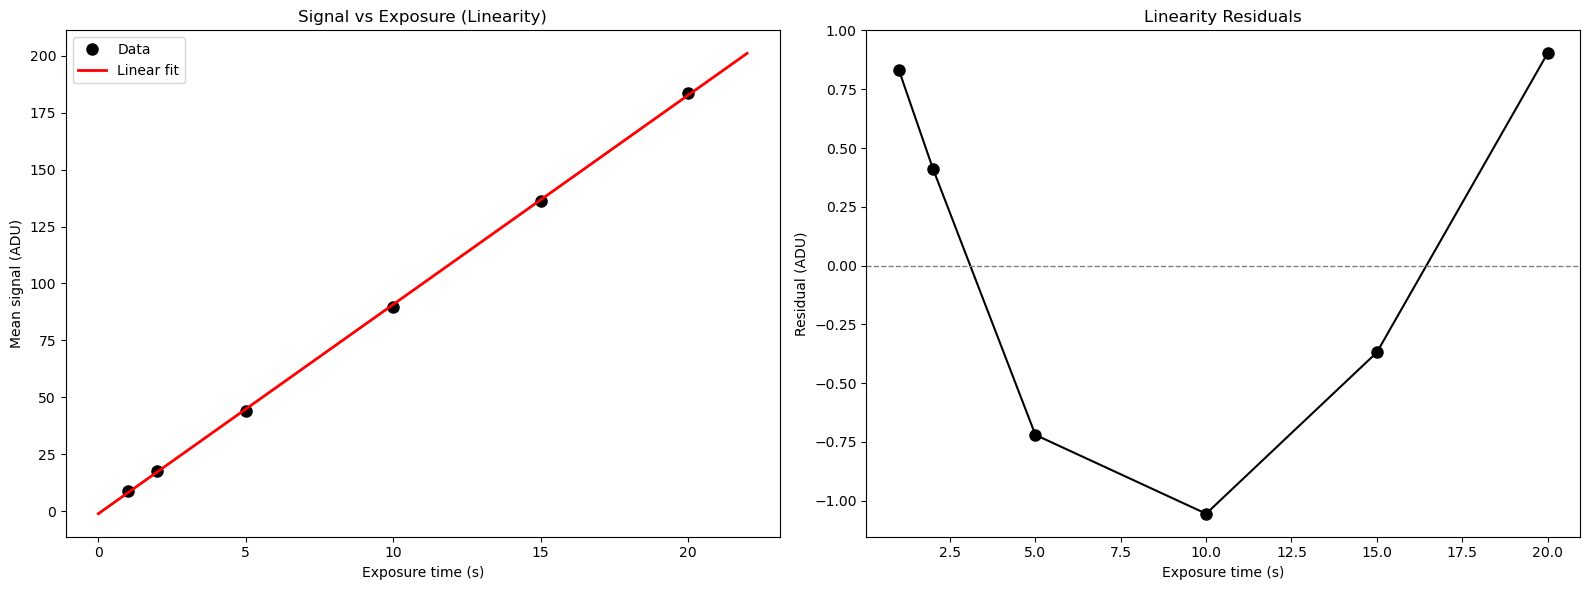

In [31]:
# ── 6b. Linearity plot ──
meta = lin_result.metadata
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: signal vs exposure
axes[0].plot(meta["exptimes"], meta["mean_signals_adu"], 'ko', markersize=8, label='Data')
t_plot = np.linspace(0, meta["exptimes"].max() * 1.1, 200)
axes[0].plot(t_plot, np.polyval(meta["fit_coeffs"], t_plot), 'r-', lw=2, label='Linear fit')
axes[0].set_xlabel('Exposure time (s)'); axes[0].set_ylabel('Mean signal (ADU)')
axes[0].set_title('Signal vs Exposure (Linearity)')
axes[0].legend()

# Right: residuals
axes[1].plot(meta["exptimes"], meta["residuals_adu"], 'ko-', markersize=8)
axes[1].axhline(0, ls='--', color='gray', lw=1)
axes[1].set_xlabel('Exposure time (s)'); axes[1].set_ylabel('Residual (ADU)')
axes[1].set_title('Linearity Residuals')

plt.tight_layout()
plt.savefig('tmpimg/linearity.png', dpi=150, bbox_inches='tight')
plt.show()

Fractional Linearity Error:
  Max |LE| = 10.2928%
  Linear range (|LE| < 1%): 15.0 – 20.0 s


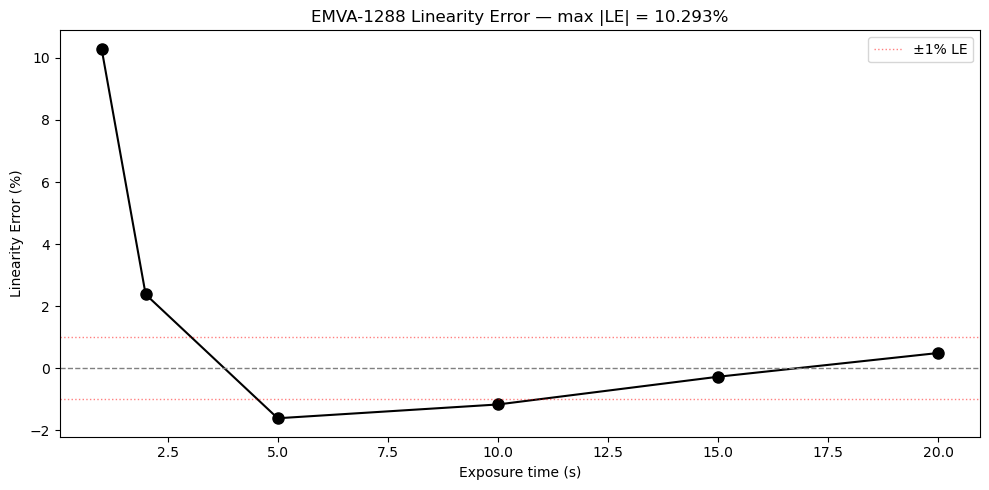

In [32]:
# ── 6c. Fractional Linearity Error ──
le_result = ct.linearity_error(lin_result)
les = le_result.scalar_summary

print(f"Fractional Linearity Error:")
print(f"  Max |LE| = {les['max_le_percent']:.4f}%")
print(f"  Linear range (|LE| < 1%): {les['linear_range_min_s']:.1f} – {les['linear_range_max_s']:.1f} s")

fig, ax = plt.subplots(figsize=(10, 5))
le_meta = le_result.metadata
ax.plot(le_meta["exptimes"], le_meta["le_percent"], 'ko-', markersize=8)
ax.axhline(0, ls='--', color='gray', lw=1)
ax.axhline(1, ls=':', color='red', lw=1, alpha=0.5, label='±1% LE')
ax.axhline(-1, ls=':', color='red', lw=1, alpha=0.5)
ax.set_xlabel('Exposure time (s)'); ax.set_ylabel('Linearity error (%)')
ax.set_title(f'Fractional linearity error — max |LE| = {les["max_le_percent"]:.3f}%')
ax.legend()
plt.tight_layout()
plt.savefig('tmpimg/linearity_error.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── 6d. Step 6 Summary ──
print("=" * 65)
print("  STEP 6: LINEARITY — QHY268M (IMX571)")
print("=" * 65)
print(f"  R²:                {ls_['r_squared']:.8f}")
print(f"  Max |LE|:          {les['max_le_percent']:.4f}%")
print(f"  Linear range:      {les['linear_range_min_s']:.1f} – {les['linear_range_max_s']:.1f} s")
print(f"  Slope:             {ls_['slope_adu_per_s']:.4f} ADU/s")
print("=" * 65)

  STEP 6: LINEARITY — QHY268M (IMX571)
  R²:                0.99985763
  Max |LE|:          10.2928%
  Linear range:      15.0 – 20.0 s
  Slope:             9.1885 ADU/s


# ─── Step 7: Photo-Response Non-Uniformity (PRNU) ───

PRNU = pixel-to-pixel sensitivity variation, measured as the standard deviation of the normalized master flat from the 30-frame 5s zenith flat stack.

In [34]:
# ── 7a. PRNU measurement ──
prnu_result = ct.prnu_map(flat5_prnu_files, master_bias, config, roi=roi)
ps_ = prnu_result.scalar_summary

print(f"PRNU:")
print(f"  σ(normalized flat) = {ps_['prnu_std']:.6f}")
print(f"  PRNU = {ps_['prnu_percent']:.4f}%")
print(f"  N frames: {ps_['n_frames']}")

PRNU:
  σ(normalized flat) = 0.265651
  PRNU = 26.5651%
  N frames: 30


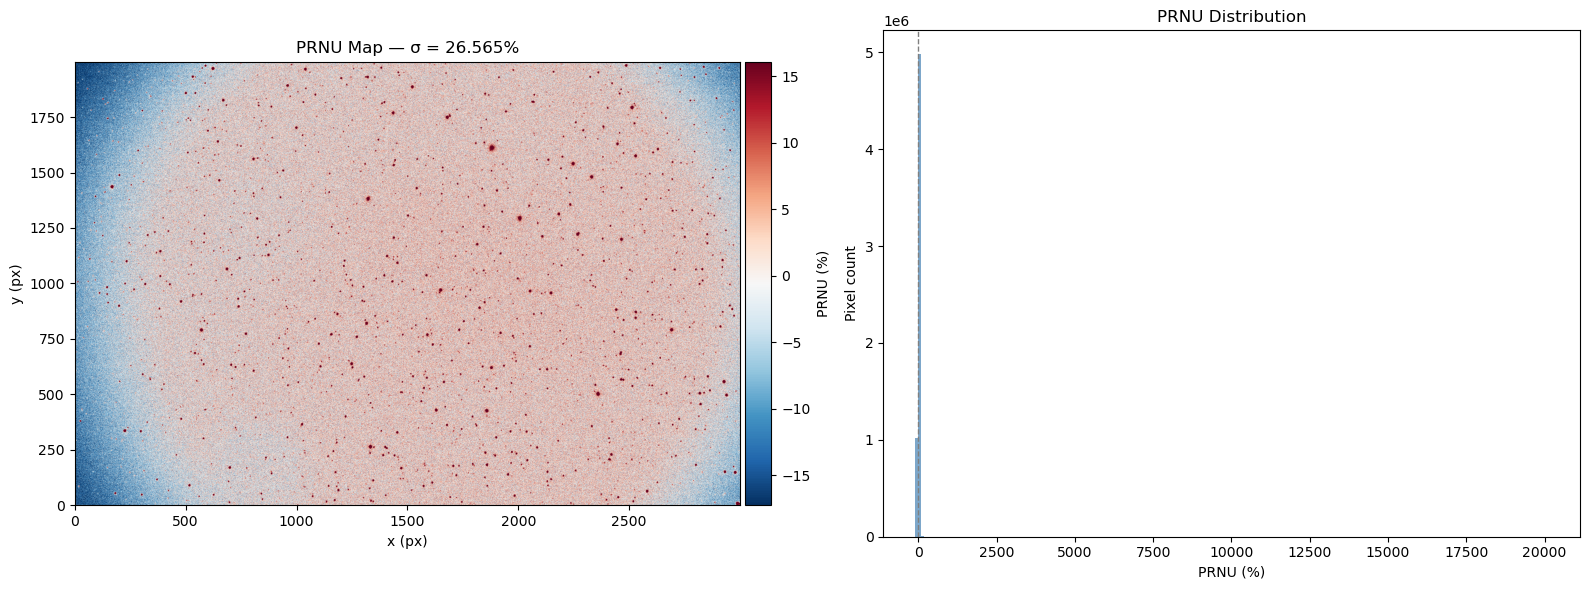

In [35]:
# ── 7b. PRNU map and histogram ──
prnu_map_data = prnu_result.maps["prnu_map"]

fig = plt.figure(figsize=(16, 6))
ax_map, ax_hist = fig.subplots(1, 2)

ct.image_with_colorbar(ax_map, prnu_map_data * 100, label='PRNU (%)', cmap='RdBu_r',
                       percentile_clip=(1, 99))
ax_map.set_title(f'PRNU Map — σ = {ps_["prnu_percent"]:.3f}%')

ax_hist.hist(prnu_map_data.ravel() * 100, bins=200, color='steelblue', alpha=0.7)
ax_hist.axvline(0, ls='--', color='gray', lw=1)
ax_hist.set_xlabel('PRNU (%)'); ax_hist.set_ylabel('Pixel count')
ax_hist.set_title('PRNU Distribution')

plt.tight_layout()
plt.savefig('tmpimg/prnu.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# ── 7c. Step 7 Summary ──
print("=" * 65)
print("  STEP 7: PRNU — QHY268M (IMX571)")
print("=" * 65)
print(f"  PRNU:              {ps_['prnu_percent']:.4f}%")
print(f"  Frames:            {ps_['n_frames']} × 5s zenith flats")
print("=" * 65)

  STEP 7: PRNU — QHY268M (IMX571)
  PRNU:              26.5651%
  Frames:            30 × 5s zenith flats


# ─── Step 8: DSNU & Fixed Pattern Noise ───

DSNU: Dark Signal Non-Uniformity — spatial variation of dark signal, decomposed into pixel/row/column components.

FPN: Fixed Pattern Noise — isolated by quadrature subtraction of frame-differencing RON from temporal std.

In [37]:
# ── 8a. DSNU ──
dsnu_result = ct.dsnu(master_darks, master_bias, config)
dsnu_s = dsnu_result.scalar_summary

print("DSNU decomposition:")
for exp in sorted(master_darks.keys()):
    total = dsnu_s.get(f'dsnu_total_{exp}s_adu', 0)
    row = dsnu_s.get(f'dsnu_row_{exp}s_adu', 0)
    col = dsnu_s.get(f'dsnu_col_{exp}s_adu', 0)
    pix = dsnu_s.get(f'dsnu_pixel_{exp}s_adu', 0)
    print(f"  {exp:6.0f}s: total = {total:.3f}, row = {row:.3f}, "
          f"col = {col:.3f}, pixel = {pix:.3f} ADU")

DSNU decomposition:
      30s: total = 15.292, row = 0.193, col = 0.078, pixel = 15.292 ADU
     120s: total = 35.681, row = 0.325, col = 0.249, pixel = 35.681 ADU
     300s: total = 53.558, row = 0.326, col = 0.072, pixel = 53.557 ADU



Fixed Pattern Noise:
  FPN mean:      0.8760 ADU
  FPN median:    0.0000 ADU
  FPN fraction:  11.78% of temporal σ
  Temporal σ:    7.4370 ADU
  RON (diff):    7.4626 ADU


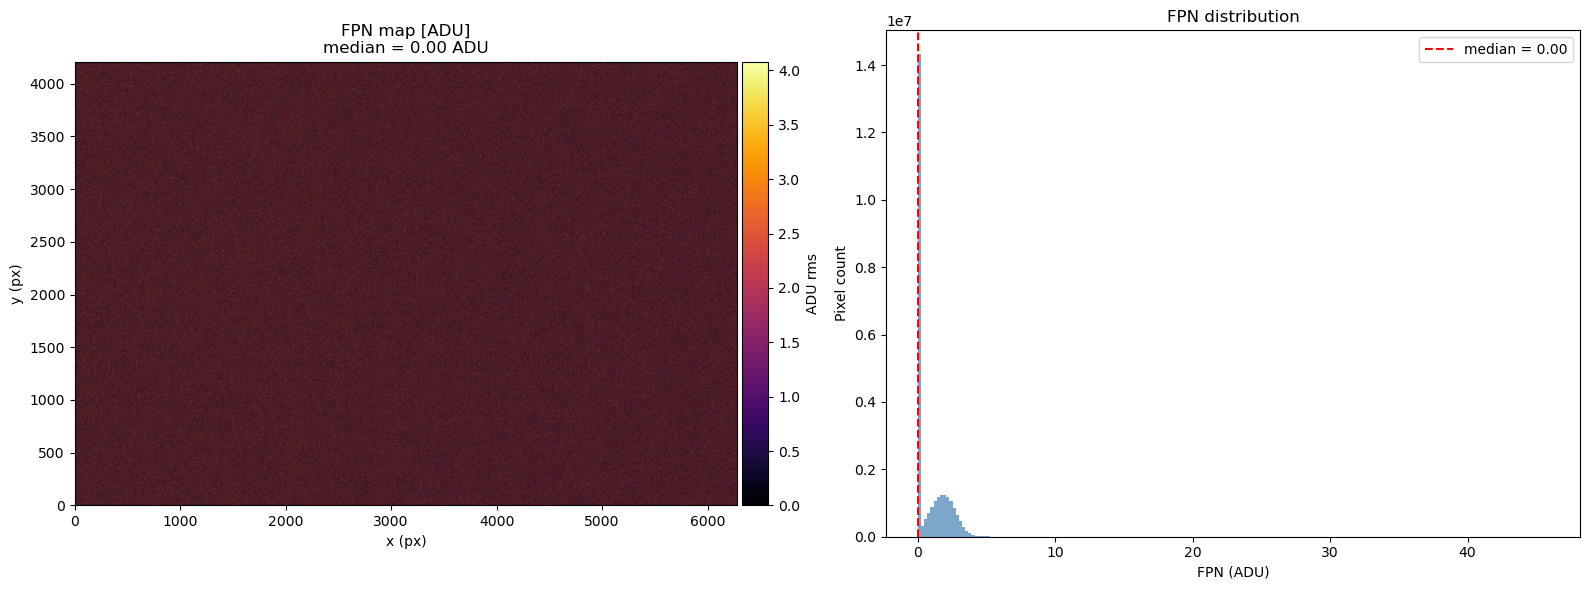

In [38]:
# ── 8b. FPN from bias frames ──
fpn_result = ct.fpn(temporal_std_map, read_noise_map_adu)
fpn_s = fpn_result.scalar_summary

print(f"\nFixed Pattern Noise:")
print(f"  FPN mean:      {fpn_s['fpn_mean_adu']:.4f} ADU")
print(f"  FPN median:    {fpn_s['fpn_median_adu']:.4f} ADU")
print(f"  FPN fraction:  {fpn_s['fpn_fraction']*100:.2f}% of temporal σ")
print(f"  Temporal σ:    {fpn_s['temporal_std_mean_adu']:.4f} ADU")
print(f"  RON (diff):    {fpn_s['ron_mean_adu']:.4f} ADU")

fig = plt.figure(figsize=(16, 6))
ct.noise_map_with_histogram(fig, fpn_result.maps["fpn_map"],
                             label="FPN", unit="ADU", cmap="inferno")
plt.savefig('tmpimg/fpn_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ── 8c. Step 8 Summary ──
print("=" * 65)
print("  STEP 8: DSNU & FPN — QHY268M (IMX571)")
print("=" * 65)
print(f"  FPN mean:          {fpn_s['fpn_mean_adu']:.4f} ADU")
print(f"  FPN fraction:      {fpn_s['fpn_fraction']*100:.2f}% of temporal σ")
for exp in sorted(master_darks.keys()):
    total = dsnu_s.get(f'dsnu_total_{exp}s_adu', 0)
    print(f"  DSNU {exp:.0f}s:       {total:.3f} ADU"
          f" = {total*GAIN_E_PER_ADU:.3f} e⁻")
print("=" * 65)

  STEP 8: DSNU & FPN — QHY268M (IMX571)
  FPN mean:          0.8760 ADU
  FPN fraction:      11.78% of temporal σ
  DSNU 30s:       15.292 ADU = 0.629 e⁻
  DSNU 120s:       35.681 ADU = 1.469 e⁻
  DSNU 300s:       53.558 ADU = 2.204 e⁻


# ─── Step 9: Temporal Stability ───

Assess within-session stability using timestamps from all frame types.
This is a partial analysis — multi-night data needed for long-term trends.

In [40]:
# ── 9a. Timestamp analysis ──
all_timestamps = ct.get_timestamps(sorted(all_files))
valid_mask = ~np.isnat(all_timestamps)
valid_ts = all_timestamps[valid_mask]

if len(valid_ts) > 1:
    t_start = valid_ts.min()
    t_end = valid_ts.max()
    duration = (t_end - t_start) / np.timedelta64(1, 'h')
    print(f"Session span: {t_start} to {t_end}")
    print(f"Duration: {duration:.2f} hours")

    # Frame-to-frame cadence
    dt = np.diff(valid_ts.astype('float64')) / 1e9  # seconds
    print(f"\nFrame cadence:")
    print(f"  Median: {np.median(dt):.1f}s")
    print(f"  Min:    {np.min(dt):.1f}s")
    print(f"  Max:    {np.max(dt):.1f}s")
else:
    duration = 0
    print("  WARNING: Insufficient timestamps for stability analysis")

Session span: 2026-03-03T04:46:36.296 to 2026-03-03T07:10:18.190
Duration: 2.39 hours

Frame cadence:
  Median: 0.0s
  Min:    0.0s
  Max:    0.0s


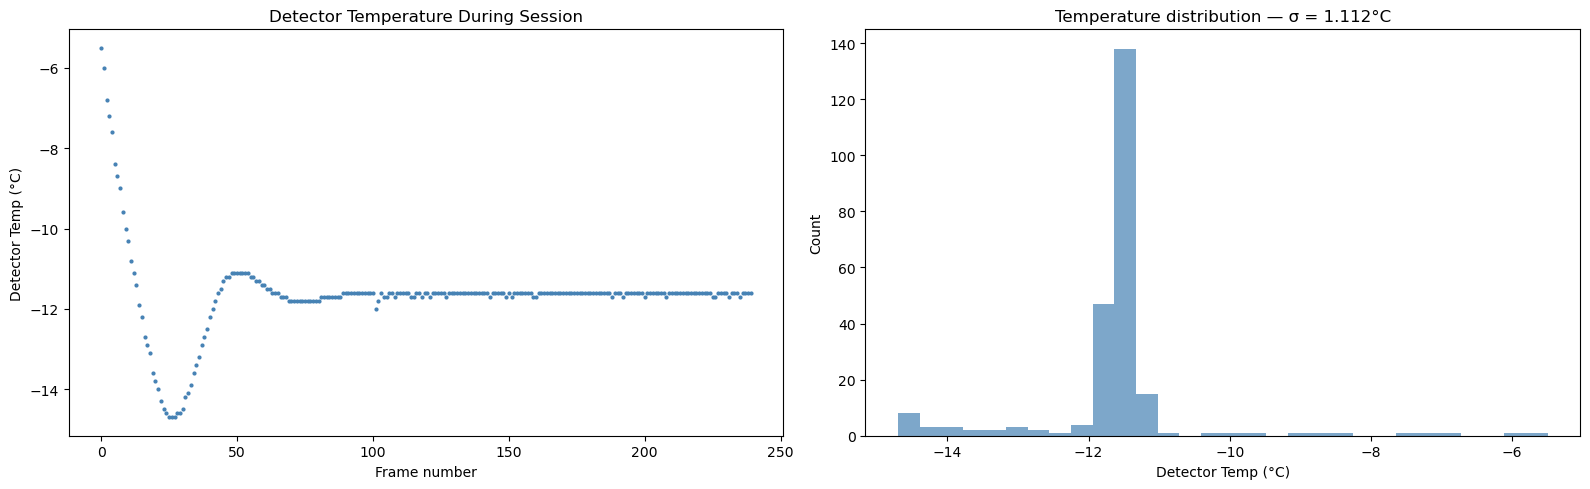

Temperature range: -14.70 – -5.50°C
Temperature σ:     1.112°C
Temperature MAD-σ: 0.000°C


In [41]:
# ── 9b. Temperature stability ──
temps = np.array([fits.getheader(f)['CCD-TEMP'] for f in sorted(all_files)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(temps, 'o', markersize=2, color='steelblue')
axes[0].set_xlabel('Frame number'); axes[0].set_ylabel('Detector Temp (°C)')
axes[0].set_title('Detector Temperature During Session')

axes[1].hist(temps, bins=30, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Detector Temp (°C)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Temperature distribution — σ = {np.std(temps):.3f}°C')

plt.tight_layout()
plt.savefig('tmpimg/temp_stability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Temperature range: {temps.min():.2f} – {temps.max():.2f}°C")
print(f"Temperature σ:     {np.std(temps):.3f}°C")
print(f"Temperature MAD-σ: {ct.mad_sigma(temps):.3f}°C")

In [42]:
# ── 9c. Step 9 Summary ──
print("=" * 65)
print("  STEP 9: TEMPORAL STABILITY (PARTIAL)")
print("=" * 65)
print(f"  Session duration:  {duration:.2f} hours")
print(f"  Temperature range: {temps.min():.2f} – {temps.max():.2f}°C")
print(f"  Temperature σ:     {np.std(temps):.3f}°C")
print(f"  WARNING: Multi-night data needed for long-term stability trends")
print("=" * 65)

  STEP 9: TEMPORAL STABILITY (PARTIAL)
  Session duration:  2.39 hours
  Temperature range: -14.70 – -5.50°C
  Temperature σ:     1.112°C


# ─── Final Summary ───

In [43]:
# Collect all analysis results
all_results = [rn_result, ptc_result, fwc_result, nd_result,
               lin_result, le_result, prnu_result, fpn_result,
               dsnu_result, dc_result, warm_result]

summary = ct.summary_table(all_results, title="QHY268M (IMX571) Detector Characterization — 2026-03-02")
display(Markdown(summary))

## QHY268M (IMX571) Detector Characterization — 2026-03-02

| Analysis | Parameter | Value |
|---|---|---|
| read_noise_spatial | ron_median_adu | 7.2856 |
| read_noise_spatial | ron_median_e | 7.2856 |
| read_noise_spatial | ron_rms_adu | 7.5899 |
| read_noise_spatial | ron_rms_e | 7.5899 |
| read_noise_spatial | mad_sigma_adu | 0.6987835168838501 |
| read_noise_spatial | hot_3sig | 902975 |
| read_noise_spatial | hot_5sig | 522540 |
| read_noise_spatial | hot_10sig | 198868 |
| photon_transfer_curve | gain_free_e_per_adu | 0.0412 |
| photon_transfer_curve | gain_free_uncertainty | 0.0000 |
| photon_transfer_curve | gain_fixed_e_per_adu | 0.0467 |
| photon_transfer_curve | ron_from_intercept_adu | 0.0000 |
| photon_transfer_curve | slope_free | 24.2951 |
| photon_transfer_curve | intercept_free | -1728.2447 |
| photon_transfer_curve | slope_fixed | 21.4019 |
| photon_transfer_curve | ron_var_prior_adu2 | 57.6066 |
| photon_transfer_curve | n_pairs | 630 |
| photon_transfer_curve | signal_min_adu | 8.9107 |
| photon_transfer_curve | signal_max_adu | 1063.9598 |
| full_well_capacity | fwc_adu | 43.6253 |
| full_well_capacity | fwc_e | 1.7956 |
| full_well_capacity | max_signal_adu | 1063.9598 |
| full_well_capacity | max_signal_e | 43.7932 |
| full_well_capacity | is_lower_bound | 0.0000 |
| noise_decomposition | ron_adu | 10.1917 |
| noise_decomposition | ron_e | 0.4195 |
| noise_decomposition | crossover_signal_adu | 4.2754 |
| noise_decomposition | crossover_signal_e | 0.1760 |
| linearity_test | slope_adu_per_s | 9.1885 |
| linearity_test | slope_e_per_s | 0.3782 |
| linearity_test | intercept_adu | -1.1030 |
| linearity_test | r_squared | 0.9999 |
| linearity_test | rms_residual_adu | 0.7581 |
| linearity_test | max_residual_adu | 1.0560 |
| linearity_error | max_le_percent | 10.2928 |
| linearity_error | linear_range_min_s | 15.0000 |
| linearity_error | linear_range_max_s | 20.0000 |
| prnu | prnu_std | 0.2657 |
| prnu | prnu_percent | 26.5651 |
| prnu | flat_median_adu | 1.0000 |
| prnu | flat_mean_adu | 1.0042 |
| prnu | n_frames | 30 |
| fpn | fpn_mean_adu | 0.8760 |
| fpn | fpn_median_adu | 0.0000 |
| fpn | fpn_max_adu | 45.8868 |
| fpn | temporal_std_mean_adu | 7.4370 |
| fpn | ron_mean_adu | 7.4626 |
| fpn | fpn_fraction | 0.1178 |
| dsnu | dsnu_total_30.0s_adu | 15.2916 |
| dsnu | dsnu_total_30.0s_e | 0.6294 |
| dsnu | dsnu_row_30.0s_adu | 0.1927 |
| dsnu | dsnu_col_30.0s_adu | 0.0777 |
| dsnu | dsnu_pixel_30.0s_adu | 15.2920 |
| dsnu | dsnu_total_120.0s_adu | 35.6806 |
| dsnu | dsnu_total_120.0s_e | 1.4686 |
| dsnu | dsnu_row_120.0s_adu | 0.3253 |
| dsnu | dsnu_col_120.0s_adu | 0.2494 |
| dsnu | dsnu_pixel_120.0s_adu | 35.6812 |
| dsnu | dsnu_total_300.0s_adu | 53.5583 |
| dsnu | dsnu_total_300.0s_e | 2.2045 |
| dsnu | dsnu_row_300.0s_adu | 0.3258 |
| dsnu | dsnu_col_300.0s_adu | 0.0724 |
| dsnu | dsnu_pixel_300.0s_adu | 53.5573 |
| dark_current_vs_exposure | dark_rate_adu_per_s | 0.0044 |
| dark_current_vs_exposure | dark_rate_e_per_s | 0.0002 |
| dark_current_vs_exposure | offset_adu | 0.0820 |
| dark_current_vs_exposure | r_squared | 0.9979 |
| warm_pixel_map | n_warm_30.0s | 3036.0000 |
| warm_pixel_map | frac_warm_30.0s | 0.0005 |
| warm_pixel_map | dark_median_30.0s_adu | 0.0000 |
| warm_pixel_map | n_warm_120.0s | 7213.0000 |
| warm_pixel_map | frac_warm_120.0s | 0.0012 |
| warm_pixel_map | dark_median_120.0s_adu | 0.0000 |
| warm_pixel_map | n_warm_300.0s | 9907.0000 |
| warm_pixel_map | frac_warm_300.0s | 0.0017 |
| warm_pixel_map | dark_median_300.0s_adu | 1.0000 |

In [44]:
# ── Comprehensive summary table ──
print("=" * 75)
print("  QHY268M (IMX571) DETECTOR CHARACTERIZATION SUMMARY — 2026-03-02")
print("=" * 75)
print(f"  Detector:            {config.nx}×{config.ny} px")
print(f"  Pixel size:          {config.pixel_size_um} µm")
print(f"  Temperature:         {config.temperature_c}°C")
print(f"  Gain (PTC):          {GAIN_E_PER_ADU:.4f} e⁻/ADU  [{gain_source}]")
print()
print("  ── Read Noise ──")
print(f"  RON (median):        {rn_result.scalar_summary['ron_median_adu']:.3f} ADU"
      f" = {rn_result.scalar_summary['ron_median_adu']*GAIN_E_PER_ADU:.3f} e⁻")
print(f"  RON (RMS):           {rn_result.scalar_summary['ron_rms_adu']:.3f} ADU"
      f" = {rn_result.scalar_summary['ron_rms_adu']*GAIN_E_PER_ADU:.3f} e⁻")
print(f"  Hot pixels (>5σ):    {rn_result.scalar_summary['hot_5sig']:,}")
print(f"  RTN candidates:      {rtn_result.scalar_summary['n_sp']:,}")
print()
print("  ── Dark Current ──")
print(f"  Dark rate:           {ds['dark_rate_e_per_s']:.6f} e⁻/pix/s")
print()
print("  ── Gain & FWC ──")
print(f"  Gain (free):         {gain_free:.4f} {pm} {sigma_gain_free:.4f} e⁻/ADU")
print(f"  FWC:                 {fs['fwc_e']:.0f} e⁻"
      + (" (lower bound)" if fs['is_lower_bound'] else ""))
print()
print("  ── Linearity ──")
print(f"  R²:                  {ls_['r_squared']:.8f}")
print(f"  Max |LE|:            {les['max_le_percent']:.4f}%")
print()
print("  ── PRNU ──")
print(f"  PRNU:                {ps_['prnu_percent']:.4f}%")
print()
print("  ── FPN ──")
print(f"  FPN fraction:        {fpn_s['fpn_fraction']*100:.2f}% of temporal σ")
print()
print("  ── Reference (QHY268M/IMX571 typical) ──")
print("  Gain 0: ~3.5 e⁻ RON, ~51k e⁻ FWC, ~1.0 e⁻/ADU")
print("=" * 75)

  QHY268M (IMX571) DETECTOR CHARACTERIZATION SUMMARY — 2026-03-02
  Detector:            6280×4210 px
  Pixel size:          3.76 µm
  Temperature:         -5.5°C
  Gain (PTC):          0.0412 e⁻/ADU  [PTC free-intercept]

  ── Read Noise ──
  RON (median):        7.286 ADU = 0.300 e⁻
  RON (RMS):           7.590 ADU = 0.312 e⁻
  Hot pixels (>5σ):    522,540
  RTN candidates:      18,907

  ── Dark Current ──
  Dark rate:           0.000180 e⁻/pix/s

  ── Gain & FWC ──
  Gain (free):         0.0412 ± 0.0000 e⁻/ADU
  FWC:                 2 e⁻

  ── Linearity ──
  R²:                  0.99985763
  Max |LE|:            10.2928%

  ── PRNU ──
  PRNU:                26.5651%

  ── FPN ──
  FPN fraction:        11.78% of temporal σ

  ── Reference (QHY268M/IMX571 typical) ──
  Gain 0: ~3.5 e⁻ RON, ~51k e⁻ FWC, ~1.0 e⁻/ADU
